In [1]:
import glob
import json
import os
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
from sklearn.metrics import (
    RocCurveDisplay,
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

from tqdm import tqdm
from monai import transforms 
from torch.nn.functional import one_hot
from torch import as_tensor
from monai.data import CacheDataset, DataLoader
from models import EfficientNet_pretrained

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/home/ceib/jaalzate/BIMCV-Prostate-Classification/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Useful Functions

In [4]:
from bimcv_prostate.experiments.clinical.models import EfficientNet_pretrained


def plot_mean_roc_cv(
    true_labels: Sequence[np.ndarray],
    fold_probs: Sequence[np.ndarray],
    title: str = "Mean ROC Curve with Variability",
    n_points: int = 100,
    show_folds: bool = True,
    width: int = 800,
    height: int = 600,
    out_path: Optional[str] = None,   # e.g., "outputs/figures/results/roc_cv.pdf"
    out_format: Optional[str] = None, # "pdf", "png", "svg" (overrides extension in out_path if provided)
    show: bool = True
) -> Tuple[go.Figure, Dict[str, object]]:
    """
    Parameters:
      - true_labels: list/sequence of 1D arrays with true labels per fold (0/1).
      - fold_probs:  list/sequence of 1D arrays with positive-class probabilities per fold.
      - title:       plot title.
      - n_points:    number of points to interpolate for mean FPR grid.
      - show_folds:  whether to draw individual fold ROC curves.
      - width, height: plot size.
      - out_path:    optional path to save the figure. Extension is inferred unless out_format is provided.
      - out_format:  force format ("pdf", "png", "svg"). Requires kaleido installed for static export.
      - show:        whether to call fig.show().

    Returns:
      - fig: Plotly Figure
      - metrics: dict with keys {"per_fold_auc", "mean_auc", "std_auc", "mean_fpr", "mean_tpr"}
    """
    # Coerce to numpy arrays
    y_trues: List[np.ndarray] = [np.asarray(y).ravel() for y in true_labels]
    y_probs:  List[np.ndarray] = [np.asarray(p).ravel() for p in fold_probs]

    if len(y_trues) != len(y_probs):
        raise ValueError(f"Mismatched folds: {len(y_trues)} true label sets vs {len(y_probs)} prediction sets.")

    # Compute per-fold ROC, AUC, and interpolate TPRs to common FPR grid
    mean_fpr = np.linspace(0, 1, n_points)
    tprs: List[np.ndarray] = []
    aucs: List[float] = []

    for i, (y_true, y_pred) in enumerate(zip(y_trues, y_probs)):
        if y_true.shape[0] != y_pred.shape[0]:
            raise ValueError(f"Fold {i}: labels ({y_true.shape[0]}) and preds ({y_pred.shape[0]}) length mismatch.")

        fpr, tpr, _ = roc_curve(y_true, y_pred)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

    # Mean and variability
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = float(np.std(aucs))

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    # Build figure
    fig = go.Figure()

    if show_folds:
        for i, (tpr, auc_val) in enumerate(zip(tprs, aucs)):
            fig.add_trace(go.Scatter(
                x=mean_fpr, y=tpr,
                mode='lines',
                line=dict(width=1),
                name=f'ROC fold {i} (AUC = {auc_val:.2f})',
                opacity=0.3
            ))

    fig.add_trace(go.Scatter(
        x=mean_fpr, y=mean_tpr,
        mode='lines',
        line=dict(color='blue', width=2),
        name=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})'
    ))

    fig.add_trace(go.Scatter(
        x=np.concatenate([mean_fpr, mean_fpr[::-1]]),
        y=np.concatenate([tprs_upper, tprs_lower[::-1]]),
        fill='toself',
        fillcolor='rgba(128, 128, 128, 0.2)',
        line=dict(color='rgba(255, 255, 255, 0)'),
        hoverinfo="skip",
        showlegend=True,
        name='± 1 std. dev.'
    ))

    fig.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1],
        mode='lines',
        line=dict(color='black', dash='dash'),
        name='Chance level (AUC = 0.5)'
    ))

    fig.update_layout(
        #title=dict(text=title, x=0.5),
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        legend=dict(x=0.6, y=0.05),
        width=width, height=height,
        margin=dict(l=50, r=50, t=50, b=50),
        paper_bgcolor='white',
        plot_bgcolor='white'
    )

    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray',
                     zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray',
                     zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')

    if show:
        fig.show()

    # Optional save
    if out_path is not None:
        # Decide format by parameter or file extension
        fmt = (out_format or out_path.split(".")[-1]).lower()
        if fmt not in {"png", "jpg", "jpeg", "svg", "pdf"}:
            raise ValueError(f"Unsupported format '{fmt}'. Use png/jpg/svg/pdf.")
        try:
            fig.write_image(out_path if out_format is None else f"{out_path.rsplit('.',1)[0]}.{fmt}", scale=2)
        except ValueError as e:
            # Usually means kaleido is missing
            raise RuntimeError("Static image export requires 'kaleido'. Install with: pip install -U kaleido") from e

    metrics = {
        "per_fold_auc": aucs,
        "mean_auc": float(mean_auc),
        "std_auc": std_auc,
        "mean_fpr": mean_fpr,
        "mean_tpr": mean_tpr,
    }
    return fig, metrics

def plot_roc_pr_single(
    y_true,
    y_score,
    title_prefix: str = "Model",
    threshold: float = 0.5,
    width: int = 800,
    height: int = 600,
    out_path_roc: Optional[str] = None,
    out_path_pr: Optional[str] = None,
    show: bool = True,
):
    """
    Plot ROC and PR curves for a single set of predictions.
    Returns: (fig_roc, fig_pr, metrics_dict)
    """
    y_true = np.asarray(y_true).ravel().astype(int)
    y_score = np.asarray(y_score).ravel()

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    fig_roc = go.Figure()
    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines",
                                 name=f"ROC (AUC = {roc_auc:.2f})",
                                 line=dict(color="blue", width=2)))
    fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines",
                                 name="Chance level (AUC = 0.5)",
                                 line=dict(color="black", dash="dash")))
    fig_roc.update_layout(
        title=dict(text=f"{title_prefix} - ROC Curve", x=0.5),
        xaxis_title="False Positive Rate",
        yaxis_title="True Positive Rate",
        width=width, height=height,
        paper_bgcolor="white", plot_bgcolor="white",
        margin=dict(l=50, r=50, t=50, b=50),
        legend=dict(x=0.6, y=0.05),
    )
    fig_roc.update_xaxes(showgrid=True, gridwidth=1, gridcolor="lightgray",
                         zeroline=True, zerolinewidth=1, zerolinecolor="lightgray")
    fig_roc.update_yaxes(showgrid=True, gridwidth=1, gridcolor="lightgray",
                         zeroline=True, zerolinewidth=1, zerolinecolor="lightgray")

    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    fig_pr = go.Figure()
    fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode="lines",
                                name=f"PR (AUC = {pr_auc:.2f})",
                                line=dict(color="darkorange", width=2)))
    fig_pr.update_layout(
        title=dict(text=f"{title_prefix} - Precision-Recall Curve", x=0.5),
        xaxis_title="Recall",
        yaxis_title="Precision",
        width=width, height=height,
        paper_bgcolor="white", plot_bgcolor="white",
        margin=dict(l=50, r=50, t=50, b=50),
        legend=dict(x=0.6, y=0.05),
    )
    fig_pr.update_xaxes(showgrid=True, gridwidth=1, gridcolor="lightgray",
                        zeroline=True, zerolinewidth=1, zerolinecolor="lightgray")
    fig_pr.update_yaxes(showgrid=True, gridwidth=1, gridcolor="lightgray",
                        zeroline=True, zerolinewidth=1, zerolinecolor="lightgray")

    # Thresholded report
    y_pred = (y_score >= threshold).astype(int)
    cls_report = classification_report(y_true, y_pred, target_names=["Non-csPC", "csPC"])
    cm = confusion_matrix(y_true, y_pred)

    if show:
        fig_roc.show()
        fig_pr.show()
        print(cls_report)
        print("Confusion matrix:\n", cm)

    if out_path_roc is not None:
        fig_roc.write_image(out_path_roc, scale=2)
    if out_path_pr is not None:
        fig_pr.write_image(out_path_pr, scale=2)

    metrics = {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "report": cls_report,
        "confusion_matrix": cm,
        "threshold": threshold,
    }
    return fig_roc, fig_pr, metrics



def load_model(weight_path):
    state = torch.load(weight_path, map_location="cpu")["state_dict"]

    if list(state.keys())[0].startswith('model.'):
        model = EfficientNet_pretrained(
            model_name="efficientnet-b7",
            n_classes=2,
            in_channels_eff=3,
            pretrained_weights_path=None
        )
        
        print(state.keys())
        model.load_state_dict(state)
        
    else:
        model = EfficientNet_pretrained(
            model_name="efficientnet-b7",
            n_classes=2,
            in_channels_eff=3,
            pretrained_weights_path=weight_path
        )

    model.to(device).eval()
    
    return model


def load_fold_models(root_pattern):
    # root_pattern e.g. ".../logs/classification/Prostate_Picai_efficientnetb7/*/models/best-model-weights.pth"
    paths = sorted(glob.glob(root_pattern))
    models = [load_model(p) for p in paths]
    return models, paths


@torch.no_grad()
def ensemble_logits(models, dataloader, weights=None, temperatures=None):
    """
    weights: list len=M (sums to 1) or None
    temperatures: list len=M (floats) or None; divides logits before combining
    Returns stacked logits (N,2) and probs (N,2)
    """
    if weights is None:
        weights = [1.0 / len(models)] * len(models)
    if temperatures is None:
        temperatures = [1.0] * len(models)

    all_logits = []
    for batch in dataloader:
        x = batch["image"].to(device)
        batch_logits = torch.zeros(x.size(0), 2, device=device, dtype=torch.float32)
        for m, w, T in zip(models, weights, temperatures):
            l = m(x) / float(T)          # torch Tensor on GPU
            batch_logits += float(w) * l # no .numpy() here
        all_logits.append(batch_logits)

    logits = torch.cat(all_logits, dim=0)
    probs = torch.softmax(logits, dim=1)
    return logits.cpu().numpy(), probs.cpu().numpy(), all_logits

In [5]:
import kaleido
kaleido.get_chrome_sync()

PosixPath('/home/ceib/jaalzate/BIMCV-Prostate-Classification/.venv/lib/python3.9/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome')

## BIMCV Results

### Results 5 folds Derivatives

#### Validation Results

In [17]:
result_paths_der = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/results.json',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/results.json',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/results.json',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/results.json',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/results.json',
]

results_per_fold_der = []

for path in result_paths_der:
    with open(path, 'r') as f:
        results = json.load(f)
        results_per_fold_der.append(np.array(results['Validation Predictions'])[:, 1])  # Probabilities for the positive class
    


# Read original data
df = pd.read_csv('Files/data_with_splits_dep_disjoint.csv')

true_labels = df[df.split=='val']['csPC'].values[:400]
# Repeat true labels for each fold (assuming same validation set)
true_labels = [true_labels for _ in range(len(results_per_fold_der))]

In [18]:
df.split.value_counts()

split
train    3675
test      581
val       404
Name: count, dtype: int64

In [19]:
results_per_fold_der[-2].shape

(400,)

In [20]:
fig, metrics = plot_mean_roc_cv(true_labels=true_labels, fold_probs=results_per_fold_der, title="BIMCV (Derivatives) - Mean ROC Curve with Variability",
                                 out_path="outputs/figures/results/AUC_ROC_BIMCV_derivatives.pdf", out_format="pdf")

# Get classification report at 0.5 threshold
reports_per_fold = []
for i, (y_true_f, probs_f) in enumerate(zip(true_labels, results_per_fold_der), start=1):
    pred_labels_f = (probs_f >= 0.5).astype(int)
    report_f = classification_report(y_true_f, pred_labels_f, target_names=['Non-csPC', 'csPC'])
    print(f"Fold {i} classification report:\n{report_f}\n")
    reports_per_fold.append(report_f)

Fold 1 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.73      0.72      0.72       185
        csPC       0.76      0.77      0.77       215

    accuracy                           0.75       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.75      0.75       400


Fold 2 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.72      0.69      0.70       185
        csPC       0.74      0.77      0.75       215

    accuracy                           0.73       400
   macro avg       0.73      0.73      0.73       400
weighted avg       0.73      0.73      0.73       400


Fold 3 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.74      0.68      0.71       185
        csPC       0.74      0.80      0.77       215

    accuracy                           0.74       400
   macro avg       0.74      0.74   

In [21]:
# Get model weigths and temperatures based on val metrics

metrics_per_fold = metrics['per_fold_auc']
total_metric = sum(metrics_per_fold)
model_weights = [m / total_metric for m in metrics_per_fold]
temperatures = [1.0 for _ in metrics_per_fold]  # No temperature scaling

In [22]:
model_weights

[0.20708411101257843,
 0.19262327883442557,
 0.20670954440535153,
 0.1980977138631263,
 0.19548535188451824]

Brier (uncalibrated): 0.1907
Brier (isotonic):     0.1802
Brier (Platt):        0.1842


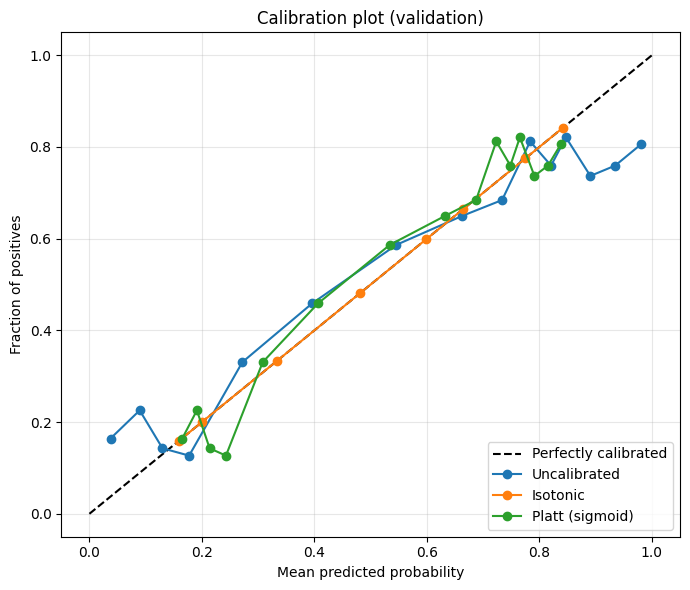

In [15]:
# Model Calibration 
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# Aggregate validation labels and probabilities
y_true_val = np.concatenate(true_labels) if isinstance(true_labels, (list, tuple)) else true_labels
y_prob_val = np.concatenate(results_per_fold_der)

# Fit calibrators

iso_calibrator = IsotonicRegression(out_of_bounds="clip")
iso_calibrator.fit(y_prob_val, y_true_val)
y_prob_iso = iso_calibrator.transform(y_prob_val)

platt_calibrator = LogisticRegression(solver="lbfgs", max_iter=1000)
platt_calibrator.fit(y_prob_val.reshape(-1, 1), y_true_val)
y_prob_platt = platt_calibrator.predict_proba(y_prob_val.reshape(-1, 1))[:, 1]

# Calibration curves
prob_true_uncal, prob_pred_uncal = calibration_curve(y_true_val, y_prob_val, n_bins=15, strategy="quantile")
prob_true_iso,   prob_pred_iso   = calibration_curve(y_true_val, y_prob_iso, n_bins=15, strategy="quantile")
prob_true_platt, prob_pred_platt = calibration_curve(y_true_val, y_prob_platt, n_bins=15, strategy="quantile")

# Brier scores
brier_uncal = brier_score_loss(y_true_val, y_prob_val)
brier_iso   = brier_score_loss(y_true_val, y_prob_iso)
brier_platt = brier_score_loss(y_true_val, y_prob_platt)
print(f"Brier (uncalibrated): {brier_uncal:.4f}")
print(f"Brier (isotonic):     {brier_iso:.4f}")
print(f"Brier (Platt):        {brier_platt:.4f}")

# Reliability diagram
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.plot(prob_pred_uncal, prob_true_uncal, marker="o", label="Uncalibrated")
plt.plot(prob_pred_iso, prob_true_iso, marker="o", label="Isotonic")
plt.plot(prob_pred_platt, prob_true_platt, marker="o", label="Platt (sigmoid)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration plot (validation)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/results/calibration_curve_bimcv_validation.pdf", dpi=300)
plt.show()

# Helper to apply chosen calibrator to new probabilities
def apply_calibration(probs: np.ndarray, method: str = "isotonic") -> np.ndarray:
    if method == "isotonic":
        return iso_calibrator.transform(np.asarray(probs).ravel())
    elif method == "platt":
        return platt_calibrator.predict_proba(np.asarray(probs).ravel().reshape(-1, 1))[:, 1]
    else:
        raise ValueError("method must be 'isotonic' or 'platt'")
    
# # Show metrics on validation set
# all_probs_calibrated = apply_calibration(all_probs, method="platt")
# pred_labels_calibrated = (all_probs_calibrated >= 0.5).astype(int)
# report_calibrated = classification_report(all_true, pred_labels_calibrated, target_names=['Non-csPC', 'csPC'])
# print(report_calibrated)
    


##### Ensemble models

In [2]:
from bimcv_prostate.data.dataloaders import ProstateImageDataLoader as Dataloader

dataloader = Dataloader(path='Files/data_with_splits_dep_disjoint.csv',partition_column="split")
val_dataloader = dataloader(partition='val')

Loading dataset: 100%|██████████| 404/404 [03:18<00:00,  2.04it/s]


In [6]:
model_paths = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/models/best-model-weights.pth',

]

models = [load_model(p) for p in model_paths]


odict_keys(['model._conv_stem.weight', 'model._bn0.weight', 'model._bn0.bias', 'model._bn0.running_mean', 'model._bn0.running_var', 'model._bn0.num_batches_tracked', 'model._blocks.0.0._depthwise_conv.weight', 'model._blocks.0.0._bn1.weight', 'model._blocks.0.0._bn1.bias', 'model._blocks.0.0._bn1.running_mean', 'model._blocks.0.0._bn1.running_var', 'model._blocks.0.0._bn1.num_batches_tracked', 'model._blocks.0.0._se_reduce.weight', 'model._blocks.0.0._se_reduce.bias', 'model._blocks.0.0._se_expand.weight', 'model._blocks.0.0._se_expand.bias', 'model._blocks.0.0._project_conv.weight', 'model._blocks.0.0._bn2.weight', 'model._blocks.0.0._bn2.bias', 'model._blocks.0.0._bn2.running_mean', 'model._blocks.0.0._bn2.running_var', 'model._blocks.0.0._bn2.num_batches_tracked', 'model._blocks.0.1._depthwise_conv.weight', 'model._blocks.0.1._bn1.weight', 'model._blocks.0.1._bn1.bias', 'model._blocks.0.1._bn1.running_mean', 'model._blocks.0.1._bn1.running_var', 'model._blocks.0.1._bn1.num_batches_t

In [7]:
results_per_fold_der_val = []
for i, m in enumerate(tqdm(models, desc="Models", unit="model")):
    fold_probs = []
    for batch in tqdm(val_dataloader, desc=f"Model {i+1}/{len(models)}", leave=False, unit="batch"):
        x = batch["image"].to(device)
        with torch.no_grad():
            logits = m(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[:, 1]  # Positive class probability
        fold_probs.append(probs) 
    results_per_fold_der_val.append(np.concatenate(fold_probs))

Models: 100%|██████████| 5/5 [02:10<00:00, 26.18s/model]


In [11]:
true_labels = df[df['split'] == 'val']['csPC'].values
true_labels = [true_labels for _ in range(len(results_per_fold_der_val))]
fig, metrics = plot_mean_roc_cv(true_labels=true_labels, fold_probs=results_per_fold_der_val, title="BIMCV(Derivatives) - Mean ROC Curve with Variability",
                                 out_path="outputs/figures/results/AUC_ROC_BIMCV_derivatives.pdf", out_format="pdf")

# Get classification report at 0.5 threshold
reports_per_fold = []
for i, (y_true_f, probs_f) in enumerate(zip(true_labels, results_per_fold_der_val), start=1):
    pred_labels_f = (probs_f >= 0.5).astype(int)
    report_f = classification_report(y_true_f, pred_labels_f, target_names=['Non-csPC', 'csPC'])
    print(f"Fold {i} classification report:\n{report_f}\n")
    reports_per_fold.append(report_f)

Fold 1 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.74      0.72      0.73       189
        csPC       0.76      0.77      0.76       215

    accuracy                           0.75       404
   macro avg       0.75      0.75      0.75       404
weighted avg       0.75      0.75      0.75       404


Fold 2 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.72      0.69      0.70       189
        csPC       0.74      0.77      0.75       215

    accuracy                           0.73       404
   macro avg       0.73      0.73      0.73       404
weighted avg       0.73      0.73      0.73       404


Fold 3 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.75      0.67      0.71       189
        csPC       0.74      0.80      0.77       215

    accuracy                           0.74       404
   macro avg       0.74      0.74   

In [12]:
import numpy as np
from scipy import stats

def fast_delong(predictions_sorted_transposed, label_1_count):
    """Fast DeLong method for computing covariance of AUCs."""
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    # Compute midranks efficiently
    def compute_midrank(x):
        J = np.argsort(x)
        Z = x[J]
        N = len(x)
        T = np.zeros(N, dtype=float)
        i = 0
        while i < N:
            j = i
            while j < N and Z[j] == Z[i]: j += 1
            T[i:j] = 0.5 * (i + j - 1) + 1
            i = j
        T2 = np.empty(N, dtype=float); T2[J] = T
        return T2

    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01); sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def compute_auc_ci(y_true, y_pred, alpha=0.95):
    """Returns (AUC, CI_lower, CI_upper) using DeLong method on pooled data."""
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    # DeLong expects positive labels first
    order = np.argsort(y_true)[::-1]
    y_true = y_true[order]; y_pred = y_pred[order]
    n_pos = int(y_true.sum())
    if n_pos == 0 or n_pos == len(y_true): return np.nan, np.nan, np.nan
    
    aucs, delongcov = fast_delong(y_pred.reshape(1, -1), n_pos)
    auc = aucs[0]
    std_err = np.sqrt(delongcov.item() if np.ndim(delongcov)==0 else delongcov[0,0])
    z = stats.norm.ppf(0.5 + alpha / 2)
    return auc, max(0.0, auc - z*std_err), min(1.0, auc + z*std_err)

def get_pvalue_compare_models(y_true, y_pred_a, y_pred_b):
    """Returns p-value for difference between Model A and Model B."""
    y_true = np.array(y_true); y_pred_a = np.array(y_pred_a); y_pred_b = np.array(y_pred_b)
    order = np.argsort(y_true)[::-1]
    y_true = y_true[order]; y_pred_a = y_pred_a[order]; y_pred_b = y_pred_b[order]
    n_pos = int(y_true.sum())
    
    preds = np.stack([y_pred_a, y_pred_b])
    aucs, sigma = fast_delong(preds, n_pos)
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    return 2 * (1 - stats.norm.cdf(z[0][0]))

In [14]:
import numpy as np
import pandas as pd
import json

# 1. Cargar el dataframe original
df = pd.read_csv('Files/data_with_splits_dep_disjoint.csv')
val_labels_full = df[df.split=='val']['csPC'].values

# 2. Cargar predicciones y alinear longitudes
result_paths_der = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/results.json',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/results.json',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/results.json',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/results.json',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/results.json',
]

y_probs_list = []
y_true_list = []

for path in result_paths_der:
    with open(path, 'r') as f:
        data = json.load(f)
    
    # Obtener probabilidades del fold
    probs = np.array(data['Validation Predictions'])
    if probs.ndim == 2:
        probs = probs[:, 1] # Quedarse con la clase positiva
    
    # --- CORRECCIÓN CLAVE ---
    # Recortar las etiquetas reales para que coincidan con el nº de predicciones de este fold
    n_preds = len(probs)
    labels_fold = val_labels_full[:n_preds] # Asume que el orden se preserva y solo faltan los últimos
    
    y_probs_list.append(probs)
    y_true_list.append(labels_fold)
    
    print(f"Fold cargado: Preds={len(probs)}, Labels={len(labels_fold)}")

# 3. Concatenar (Pooling)
y_pred_der_all = np.concatenate(y_probs_list)
y_true_all = np.concatenate(y_true_list)

print(f"\nDimensiones finales -> y_true: {y_true_all.shape}, y_pred: {y_pred_der_all.shape}")

# 4. Calcular AUC con intervalo de confianza
# (Asegúrate de tener cargadas las funciones 'compute_auc_ci' que te pasé antes)
auc_der, ci_lo, ci_hi = compute_auc_ci(y_true_all, y_pred_der_all)

print(f"DER Model (Pooled): AUC = {auc_der:.3f} (95% CI: {ci_lo:.3f}-{ci_hi:.3f})")

Fold cargado: Preds=400, Labels=400
Fold cargado: Preds=400, Labels=400
Fold cargado: Preds=400, Labels=400
Fold cargado: Preds=400, Labels=400
Fold cargado: Preds=400, Labels=400

Dimensiones finales -> y_true: (2000,), y_pred: (2000,)
DER Model (Pooled): AUC = 0.778 (95% CI: 0.757-0.799)


#### Check pretrained models vs no pretrained one

##### ensemble vs average models vs no pretrained

In [23]:
model_paths_pretrained = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/models/best-model-weights.pth',
]

no_pretrained_path = 'logs/classification/Prostate_BIMCV_no_pretrained/15-Sep-2025-14:51:00/models/best-model-weights.pth'

models_pretrained = [load_model(p) for p in model_paths]
no_pretrained_model = load_model(no_pretrained_path)

odict_keys(['model._conv_stem.weight', 'model._bn0.weight', 'model._bn0.bias', 'model._bn0.running_mean', 'model._bn0.running_var', 'model._bn0.num_batches_tracked', 'model._blocks.0.0._depthwise_conv.weight', 'model._blocks.0.0._bn1.weight', 'model._blocks.0.0._bn1.bias', 'model._blocks.0.0._bn1.running_mean', 'model._blocks.0.0._bn1.running_var', 'model._blocks.0.0._bn1.num_batches_tracked', 'model._blocks.0.0._se_reduce.weight', 'model._blocks.0.0._se_reduce.bias', 'model._blocks.0.0._se_expand.weight', 'model._blocks.0.0._se_expand.bias', 'model._blocks.0.0._project_conv.weight', 'model._blocks.0.0._bn2.weight', 'model._blocks.0.0._bn2.bias', 'model._blocks.0.0._bn2.running_mean', 'model._blocks.0.0._bn2.running_var', 'model._blocks.0.0._bn2.num_batches_tracked', 'model._blocks.0.1._depthwise_conv.weight', 'model._blocks.0.1._bn1.weight', 'model._blocks.0.1._bn1.bias', 'model._blocks.0.1._bn1.running_mean', 'model._blocks.0.1._bn1.running_var', 'model._blocks.0.1._bn1.num_batches_t

In [24]:
#Ensemble pretrained logits
logits_ensemble, probs_ensemble, _ = ensemble_logits(models_pretrained, val_dataloader, weights=model_weights)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

@torch.no_grad()
def _collect_logit_features(models, dataloader, device):
    """
    Returns:
      - X: (N, M) features, one column per model = logit_margin = logits[:,1]-logits[:,0]
      - y: (N,) int labels from dataloader.dataset (assumes one-hot 'label')
    """
    feats = []
    for batch in tqdm(dataloader, desc="Stacking features", leave=False, unit="batch"):
        x = batch["image"].to(device)
        cols = []
        for m in models:
            m.eval()
            logits = m(x)  # (B,2) on device
            margin = (logits[:, 1] - logits[:, 0]).detach().cpu().numpy()  # (B,)
            cols.append(margin[:, None])
        feats.append(np.concatenate(cols, axis=1))  # (B, M)
    X = np.concatenate(feats, axis=0)  # (N, M)

    # y from dataset one-hot labels
    y = np.array([int(sample["label"][1]) for sample in dataloader.dataset])
    return X, y

def fit_logreg_ensemble(models, dataloader, device, C=1.0, max_iter=2000, class_weight="balanced"):
    """
    Fits a logistic regression meta-model over per-model logit margins.
    Returns:
      - clf: fitted sklearn Pipeline(StandardScaler + LogisticRegression)
      - probs_val: (N,2) stacked probabilities on the provided dataloader
      - X, y: features and labels used to fit
    """
    X, y = _collect_logit_features(models, dataloader, device)
    clf = make_pipeline(
        # StandardScaler(),
        LogisticRegression(C=C, max_iter=max_iter, class_weight=class_weight, solver="lbfgs")
    )
    clf.fit(X, y)
    probs_pos = clf.predict_proba(X)[:, 1]
    probs_val = np.column_stack([1.0 - probs_pos, probs_pos])
    return clf, probs_val, X, y

@torch.no_grad()
def predict_logreg_ensemble(clf, models, dataloader, device):
    """
    Uses fitted clf to predict stacked probabilities on a new dataloader.
    Returns (N,2)
    """
    X_new, _ = _collect_logit_features(models, dataloader, device)
    probs_pos = clf.predict_proba(X_new)[:, 1]
    return np.column_stack([1.0 - probs_pos, probs_pos])


logreg_clf, probs_stack_val, X_stack, y_stack = fit_logreg_ensemble(models_pretrained, val_dataloader, device)

In [26]:
#logits no pretrained model
probs_no_pretrained = []
logits_no_pretrained = []

no_pretrained_model.eval()
for batch in tqdm(val_dataloader, leave=False, unit="batch"):
    x = batch["image"].to(device)
    with torch.no_grad():
        logits = no_pretrained_model(x)               # (B,2) on GPU
        probs = torch.softmax(logits, dim=1)          # (B,2) on GPU
    probs_no_pretrained.append(probs.cpu().numpy())   # to CPU -> numpy
    logits_no_pretrained.append(logits.detach().cpu())# keep as CPU tensors

# concatenate along batch dimension
probs_no_pretrained = np.concatenate(probs_no_pretrained, axis=0)     # (N,2)
logits_no_pretrained = torch.cat(logits_no_pretrained, dim=0)         # (N,2) tensor

logits_no_pretrained = logits_no_pretrained.numpy()

In [27]:
# Average models
import torch
from pathlib import Path
from typing import List, Dict
from monai.networks.nets import EfficientNetBN

from models import EfficientNet_pretrained

def load_fold_checkpoints(paths: List[Path]) -> List[Dict]:
    ckpts = []
    for p in paths:
        ckpt = torch.load(p, map_location="cpu")  # keep on CPU for averaging
        state = ckpt.get("state_dict", ckpt)
        ckpts.append(state)
    return ckpts

def average_state_dicts(state_dicts: List[Dict[str, torch.Tensor]],
                        weights: List[float],
                        exclude_keys_substrings=("classifier", "fc", "last_linear")) -> Dict[str, torch.Tensor]:
    if len(state_dicts) == 0:
        raise ValueError("No state dicts provided.")
    if len(state_dicts) != len(weights):
        raise ValueError("Weights length must match number of state dicts.")
    w = torch.tensor(weights, dtype=torch.float32)
    # w = w / w.sum()

    ref_keys = state_dicts[0].keys()
    avg_state = {}

    for k in ref_keys:
        if any(sub in k for sub in exclude_keys_substrings):
            continue

        tensors = []
        orig_dtypes = []
        for sd in state_dicts:
            if k not in sd:
                raise ValueError(f"Key {k} missing in one state_dict.")
            t = sd[k]
            tensors.append(t)
            orig_dtypes.append(t.dtype)

        # If scalar long buffer (e.g., num_batches_tracked) just take first
        if tensors[0].dtype in (torch.int64, torch.int32, torch.uint8, torch.bool):
            avg_state[k] = tensors[0]
            continue

        stacked = torch.stack([t.to(torch.float32) for t in tensors], dim=0)  # (n, ...)
        # Broadcast weights
        avg = (w.view(-1, *([1] * (stacked.ndim - 1))) * stacked).sum(dim=0)
        avg_state[k] = avg.to(tensors[0].dtype)

    return avg_state

def build_new_model_from_folds(fold_ckpt_paths: List[str],
                               weights: List[float],
                               new_num_classes: int,
                               model_name: str = "efficientnet-b0",
                               in_channels: int = 1) -> EfficientNetBN:
    states = load_fold_checkpoints([Path(p) for p in fold_ckpt_paths])
    avg_backbone = average_state_dicts(states, weights)

    model = EfficientNet_pretrained(
        model_name=model_name,
        n_classes=new_num_classes,
        in_channels_eff=in_channels,
        pretrained_weights_path=None
    )

    model_state = model.state_dict()
    loaded = 0
    skipped = []
    for k, v in avg_backbone.items():
        if k in model_state and model_state[k].shape == v.shape:
            model_state[k] = v
            loaded += 1
        else:
            skipped.append(k)
    model.load_state_dict(model_state, strict=False)
    print(f"Loaded averaged params: {loaded}. Skipped (head/mismatch): {len(skipped)}")

    # Re-init classifier head
    head_param_names = []
    for name, param in model.named_parameters():
        if "classifier" in name and param.requires_grad:
            if param.ndim >= 2:
                torch.nn.init.kaiming_normal_(param)
            else:
                torch.nn.init.zeros_(param)
            head_param_names.append(name)
    if head_param_names:
        print("Re-initialized head params:", head_param_names)

    return model


# Build averaged model
avg_model = build_new_model_from_folds(
    fold_ckpt_paths=model_paths_pretrained,
    weights=model_weights,
    new_num_classes=2,
    model_name="efficientnet-b7",
    in_channels=3
)
avg_model.to(device).eval()
#Ensemble averaged model logits

probs_avg = []
logits_avg = []

no_pretrained_model.eval()
for batch in tqdm(val_dataloader, leave=False, unit="batch"):
    x = batch["image"].to(device)
    with torch.no_grad():
        logits = avg_model(x)               # (B,2) on GPU
        probs = torch.softmax(logits, dim=1)          # (B,2) on GPU
    probs_avg.append(probs.cpu().numpy())   # to CPU -> numpy
    logits_avg.append(logits.detach().cpu())# keep as CPU tensors

# concatenate along batch dimension
probs_avg = np.concatenate(probs_avg, axis=0)     # (N,2)
logits_avg = torch.cat(logits_avg, dim=0)         # (N,2) tensor

logits_avg = logits_avg.numpy()

Loaded averaged params: 1198. Skipped (head/mismatch): 0


In [28]:
# Compare models
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc, precision_recall_curve

def compare_models_roc_pr(
    y_true,
    model_scores: dict,
    title_prefix: str = "Validation",
    width: int = 800,
    height: int = 600,
    out_path_roc: str = None,
    out_path_pr: str = None,
    show: bool = True,
):
    """
    Compare ROC and PR curves across models.
    model_scores: dict{name -> scores}, where scores are either shape (N,) or (N,2) probs.
    Returns: (fig_roc, fig_pr, metrics_dict)
    """
    y_true = np.asarray(y_true).ravel().astype(int)
    prevalence = y_true.mean() if y_true.size else 0.0

    def to_pos_scores(scores):
        # Robustly accept torch.Tensor / MetaTensor / numpy / list
        if isinstance(scores, torch.Tensor):
            s = scores.detach().cpu().numpy()
        else:
            try:
                s = np.asarray(scores)
            except TypeError:
                # Fallback if scores is e.g. list of tensors
                s = np.asarray([t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else t for t in scores])
        if s.ndim == 2 and s.shape[1] == 2:
            return s[:, 1].ravel()
        return s.ravel()

    # Collect curves and metrics
    roc_curves = {}
    pr_curves = {}
    metrics = {}
    

    for name, scores in model_scores.items():
        print(scores.shape)
        y_score = to_pos_scores(scores)
        if y_score.shape[0] != y_true.shape[0]:
            raise ValueError(f"{name}: y_true ({y_true.shape[0]}) vs scores ({y_score.shape[0]}) length mismatch.")

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        precision, recall, _ = precision_recall_curve(y_true, y_score)
        pr_auc = auc(recall, precision)

        roc_curves[name] = (fpr, tpr, roc_auc)
        pr_curves[name] = (recall, precision, pr_auc)
        metrics[name] = {"roc_auc": float(roc_auc), "pr_auc": float(pr_auc)}

    # Plot ROC
    fig_roc = go.Figure()
    for name, (fpr, tpr, roc_auc) in roc_curves.items():
        fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines",
                                     name=f"{name} (AUC = {roc_auc:.3f})"))
    fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines",
                                 line=dict(color="black", dash="dash"),
                                 name="Chance (AUC = 0.5)"))
    fig_roc.update_layout(
        # title=dict(text=f"{title_prefix} - ROC Comparison", x=0.5),
        xaxis_title="False Positive Rate",
        yaxis_title="True Positive Rate",
        width=width, height=height,
        paper_bgcolor="white", plot_bgcolor="white",
        margin=dict(l=50, r=50, t=50, b=50),
        legend=dict(x=0.02, y=0.02),
    )
    fig_roc.update_xaxes(showgrid=True, gridcolor="lightgray", zeroline=True, zerolinecolor="lightgray")
    fig_roc.update_yaxes(showgrid=True, gridcolor="lightgray", zeroline=True, zerolinecolor="lightgray")

    # Plot PR
    fig_pr = go.Figure()
    for name, (recall, precision, pr_auc_val) in pr_curves.items():
        fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode="lines",
                                    name=f"{name} (AUC = {pr_auc_val:.3f})"))
    fig_pr.add_trace(go.Scatter(x=[0, 1], y=[prevalence, prevalence], mode="lines",
                                line=dict(color="black", dash="dash"),
                                name=f"Baseline (pos rate = {prevalence:.3f})"))
    fig_pr.update_layout(
        #title=dict(text=f"{title_prefix} - Precision-Recall Comparison", x=0.5),
        xaxis_title="Recall",
        yaxis_title="Precision",
        width=width, height=height,
        paper_bgcolor="white", plot_bgcolor="white",
        margin=dict(l=50, r=50, t=50, b=50),
        legend=dict(x=0.02, y=0.02),
    )
    fig_pr.update_xaxes(showgrid=True, gridcolor="lightgray", zeroline=True, zerolinecolor="lightgray")
    fig_pr.update_yaxes(showgrid=True, gridcolor="lightgray", zeroline=True, zerolinecolor="lightgray")

    if show:
        fig_roc.show()
        fig_pr.show()
    if out_path_roc:
        fig_roc.write_image(out_path_roc, scale=2)
    if out_path_pr:
        fig_pr.write_image(out_path_pr, scale=2)

    return fig_roc, fig_pr, metrics

# Example usage on your validation predictions:
# Ensure these variables exist:
#   - probs: (N,2) from ensemble_logits(models_pretrained, ...)
#   - probs_no_pretrained: (N,2) built above
#   - probs_avg: (N,2) from avg_model (note: run inference with avg_model, not no_pretrained_model)
y_true_val = np.array([int(sample["label"][1]) for sample in val_dataloader.dataset])

fig_roc_cmp, fig_pr_cmp, metrics_cmp = compare_models_roc_pr(
    y_true=y_true_val,
    model_scores={
        "Ensemble (pretrained)": probs_ensemble,
        "No-pretrained (single)": probs_no_pretrained,
        # "Averaged model": probs_avg,
        "Stacked (LogReg on logits)": probs_stack_val,
    },
    title_prefix="BIMCV Validation",
    out_path_roc="outputs/figures/results/compare_roc_bimcv_validation.pdf",
    out_path_pr="outputs/figures/results/compare_pr_bimcv_validation.pdf",
    show=True,
)
print(metrics_cmp)


(404, 2)
(404, 2)
(404, 2)


{'Ensemble (pretrained)': {'roc_auc': 0.802141011443337, 'pr_auc': 0.7575735055865989}, 'No-pretrained (single)': {'roc_auc': 0.7105820105820105, 'pr_auc': 0.7071024344112952}, 'Stacked (LogReg on logits)': {'roc_auc': 0.8160206718346253, 'pr_auc': 0.8056106079702579}}


In [29]:
# Get classification report at 0.5 threshold for each model
for name, scores in {
        "Ensemble (pretrained)": probs_ensemble,
        "No-pretrained (single)": probs_no_pretrained,
        "Averaged model": probs_avg,
        "Stacked (LogReg on logits)": probs_stack_val,
    }.items():
    y_score = scores[:, 1] if scores.ndim == 2 and scores.shape[1] == 2 else scores
    pred_labels = (y_score >= 0.5).astype(int)
    report = classification_report(y_true_val, pred_labels, target_names=['Non-csPC', 'csPC'])
    cm = confusion_matrix(y_true_val, pred_labels)
    print(f"{name} classification report:\n{report}\nConfusion matrix:\n{cm}\n")

Ensemble (pretrained) classification report:
              precision    recall  f1-score   support

    Non-csPC       0.77      0.65      0.70       189
        csPC       0.73      0.83      0.78       215

    accuracy                           0.75       404
   macro avg       0.75      0.74      0.74       404
weighted avg       0.75      0.75      0.74       404

Confusion matrix:
[[123  66]
 [ 37 178]]

No-pretrained (single) classification report:
              precision    recall  f1-score   support

    Non-csPC       0.71      0.63      0.67       189
        csPC       0.71      0.77      0.74       215

    accuracy                           0.71       404
   macro avg       0.71      0.70      0.70       404
weighted avg       0.71      0.71      0.71       404

Confusion matrix:
[[120  69]
 [ 49 166]]

Averaged model classification report:
              precision    recall  f1-score   support

    Non-csPC       0.00      0.00      0.00       189
        csPC       0.53 

/home/ceib/jaalzate/BIMCV-Prostate-Classification/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/ceib/jaalzate/BIMCV-Prostate-Classification/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/ceib/jaalzate/BIMCV-Prostate-Classification/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [30]:
import numpy as np
import torch
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc, precision_recall_curve, classification_report, confusion_matrix
from scipy import stats

# ==============================================================================
# 1. FUNCIONES ESTADÍSTICAS (DeLong Test)
# ==============================================================================

def fast_delong(predictions_sorted_transposed, label_1_count):
    """Implementación rápida del método DeLong para covarianza de AUCs."""
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    def compute_midrank(x):
        J = np.argsort(x)
        Z = x[J]
        N = len(x)
        T = np.zeros(N, dtype=float)
        i = 0
        while i < N:
            j = i
            while j < N and Z[j] == Z[i]: j += 1
            T[i:j] = 0.5 * (i + j - 1) + 1
            i = j
        T2 = np.empty(N, dtype=float); T2[J] = T
        return T2

    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01); sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def compute_auc_with_ci(y_true, y_score, alpha=0.95):
    """Calcula AUC y su Intervalo de Confianza (95%)."""
    y_true = np.array(y_true); y_score = np.array(y_score)
    order = np.argsort(y_true)[::-1]
    y_true = y_true[order]; y_score = y_score[order]
    n_pos = int(y_true.sum())
    if n_pos == 0 or n_pos == len(y_true): return np.nan, np.nan, np.nan
    
    aucs, delongcov = fast_delong(y_score.reshape(1, -1), n_pos)
    auc_val = aucs[0]
    variance = delongcov.item() if np.ndim(delongcov)==0 else delongcov[0,0]
    std_err = np.sqrt(variance)
    z = stats.norm.ppf(0.5 + alpha / 2)
    ci_lo = max(0.0, auc_val - z*std_err)
    ci_hi = min(1.0, auc_val + z*std_err)
    return auc_val, ci_lo, ci_hi

def get_pvalue_compare_models(y_true, y_score_a, y_score_b):
    """Test de DeLong pareado: Modelo A vs Modelo B."""
    y_true = np.array(y_true); y_score_a = np.array(y_score_a); y_score_b = np.array(y_score_b)
    order = np.argsort(y_true)[::-1]
    y_true = y_true[order]; y_score_a = y_score_a[order]; y_score_b = y_score_b[order]
    n_pos = int(y_true.sum())
    
    preds = np.stack([y_score_a, y_score_b])
    aucs, sigma = fast_delong(preds, n_pos)
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    return 2 * (1 - stats.norm.cdf(z[0][0]))

# ==============================================================================
# 2. FUNCIÓN DE COMPARACIÓN COMPLETA
# ==============================================================================

def compare_models_full_report(
    y_true,
    model_scores: dict,
    title_prefix: str = "Validation",
    width: int = 800,
    height: int = 600,
    out_path_roc: str = None,
    out_path_pr: str = None,
    show: bool = True,
):
    y_true = np.asarray(y_true).ravel().astype(int)
    prevalence = y_true.mean() if y_true.size else 0.0

    # Helper para extraer prob clase positiva
    def to_pos_scores(scores):
        if isinstance(scores, torch.Tensor):
            s = scores.detach().cpu().numpy()
        else:
            s = np.asarray(scores)
        if s.ndim == 2 and s.shape[1] == 2:
            return s[:, 1].ravel()
        return s.ravel()

    roc_curves = {}
    pr_curves = {}
    metrics = {}
    processed_scores = {} 

    print(f"\n{'='*60}")
    print(f"--- {title_prefix} DETAILED REPORT ---")
    print(f"{'='*60}\n")
    
    # 1. Métricas Globales (AUCs)
    for name, scores in model_scores.items():
        y_score = to_pos_scores(scores)
        processed_scores[name] = y_score
        
        if y_score.shape[0] != y_true.shape[0]:
            raise ValueError(f"{name}: length mismatch.")

        # DeLong AUC + CI
        roc_auc, ci_lo, ci_hi = compute_auc_with_ci(y_true, y_score)
        
        # PR Curve
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        pr_auc = auc(recall, precision)
        
        # ROC Curve (para plot)
        fpr, tpr, _ = roc_curve(y_true, y_score)

        roc_curves[name] = (fpr, tpr, roc_auc)
        pr_curves[name] = (recall, precision, pr_auc)
        
        metrics[name] = {
            "roc_auc": roc_auc, "ci_lo": ci_lo, "ci_hi": ci_hi, "pr_auc": pr_auc
        }
        
        print(f">>> Model: {name}")
        print(f"    ROC-AUC: {roc_auc:.3f} (95% CI: {ci_lo:.3f}-{ci_hi:.3f})")
        print(f"    PR-AUC:  {pr_auc:.3f}")
        print("-" * 30)

    # 2. Classification Report & Confusion Matrix
    print(f"\n{'='*60}")
    print("--- CLASSIFICATION REPORT (Threshold = 0.5) ---")
    print(f"{'='*60}")
    
    for name, y_score in processed_scores.items():
        pred_labels = (y_score >= 0.5).astype(int)
        report = classification_report(y_true, pred_labels, target_names=['Non-csPC', 'csPC'])
        cm = confusion_matrix(y_true, pred_labels)
        
        print(f"\nModel: {name}")
        print(report)
        print(f"Confusion Matrix:\n{cm}")
        print("-" * 40)

    # 3. Plotting ROC
    fig_roc = go.Figure()
    for name, (fpr, tpr, roc_auc) in roc_curves.items():
        ci_txt = f"[{metrics[name]['ci_lo']:.2f}-{metrics[name]['ci_hi']:.2f}]"
        fig_roc.add_trace(go.Scatter(
            x=fpr, y=tpr, mode="lines",
            name=f"{name} (AUC={roc_auc:.2f} {ci_txt})"
        ))
    fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(color="black", dash="dash"), name="Chance"))
    
    fig_roc.update_layout(
        title=dict(text=f"{title_prefix} - ROC Comparison", x=0.5),
        xaxis_title="False Positive Rate", yaxis_title="True Positive Rate",
        width=width, height=height, template="plotly_white",
        legend=dict(x=0.50, y=0.05, bgcolor='rgba(255,255,255,0.8)')
    )

    # 4. Plotting PR
    fig_pr = go.Figure()
    for name, (recall, precision, pr_auc_val) in pr_curves.items():
        fig_pr.add_trace(go.Scatter(
            x=recall, y=precision, mode="lines",
            name=f"{name} (AUC={pr_auc_val:.2f})"
        ))
    fig_pr.add_trace(go.Scatter(
        x=[0, 1], y=[prevalence, prevalence], mode="lines", 
        line=dict(color="black", dash="dash"), name=f"Baseline ({prevalence:.2f})"
    ))
    
    fig_pr.update_layout(
        title=dict(text=f"{title_prefix} - PR Comparison", x=0.5),
        xaxis_title="Recall", yaxis_title="Precision",
        width=width, height=height, template="plotly_white",
        legend=dict(x=0.05, y=0.05, bgcolor='rgba(255,255,255,0.8)')
    )

    if show:
        fig_roc.show()
        fig_pr.show()
    if out_path_roc: fig_roc.write_image(out_path_roc, scale=2)
    if out_path_pr: fig_pr.write_image(out_path_pr, scale=2)

    return fig_roc, fig_pr, metrics, processed_scores

# ==============================================================================
# 3. EJECUCIÓN
# ==============================================================================

# Asegúrate de que y_true_val y tus probabilidades (probs_*) estén definidos
y_true_val = np.array([int(sample["label"][1]) for sample in val_dataloader.dataset])

fig_roc, fig_pr, metrics_results, scores_dict = compare_models_full_report(
    y_true=y_true_val,
    model_scores={
        "Ensemble (weighted logits)": probs_ensemble,
        "Stacked (LogReg on logits)": probs_stack_val,
        "No-pretrained (single)": probs_no_pretrained,
        # "Averaged model": probs_avg, # Descomentar si lo tienes
    },
    title_prefix="BIMCV Hold-out",
    out_path_roc="outputs/figures/results/compare_roc_bimcv_validation.pdf",
    out_path_pr="outputs/figures/results/compare_pr_bimcv_validation.pdf"
)

# --- STATISTICAL TESTS (Paired DeLong) ---
print(f"\n{'='*60}")
print("--- STATISTICAL SIGNIFICANCE (Paired DeLong Test) ---")
print(f"{'='*60}")

def print_pvalue(name_a, name_b):
    p_val = get_pvalue_compare_models(y_true_val, scores_dict[name_a], scores_dict[name_b])
    print(f"{name_a} vs {name_b}")
    print(f"   p-value = {p_val:.2e} ({p_val:.5f})")
    if p_val < 0.05: print("   Result: SIGNIFICANT")
    else:            print("   Result: NOT significant")
    print("-" * 30)

# Comparaciones clave
print_pvalue("Stacked (LogReg on logits)", "No-pretrained (single)")
print_pvalue("Ensemble (weighted logits)", "No-pretrained (single)")


--- BIMCV Hold-out DETAILED REPORT ---

>>> Model: Ensemble (weighted logits)
    ROC-AUC: 0.802 (95% CI: 0.758-0.846)
    PR-AUC:  0.758
------------------------------
>>> Model: Stacked (LogReg on logits)
    ROC-AUC: 0.816 (95% CI: 0.774-0.858)
    PR-AUC:  0.806
------------------------------
>>> Model: No-pretrained (single)
    ROC-AUC: 0.711 (95% CI: 0.659-0.762)
    PR-AUC:  0.707
------------------------------

--- CLASSIFICATION REPORT (Threshold = 0.5) ---

Model: Ensemble (weighted logits)
              precision    recall  f1-score   support

    Non-csPC       0.77      0.65      0.70       189
        csPC       0.73      0.83      0.78       215

    accuracy                           0.75       404
   macro avg       0.75      0.74      0.74       404
weighted avg       0.75      0.75      0.74       404

Confusion Matrix:
[[123  66]
 [ 37 178]]
----------------------------------------

Model: Stacked (LogReg on logits)
              precision    recall  f1-score   su


--- STATISTICAL SIGNIFICANCE (Paired DeLong Test) ---
Stacked (LogReg on logits) vs No-pretrained (single)
   p-value = 9.10e-08 (0.00000)
   Result: SIGNIFICANT
------------------------------
Ensemble (weighted logits) vs No-pretrained (single)
   p-value = 2.19e-05 (0.00002)
   Result: SIGNIFICANT
------------------------------


In [29]:
probs.shape

torch.Size([1, 2])

In [86]:
#Show metrics and plots
probs_pos = probs#[:, 1]  # Probabilities for the positive class
y_true_val = np.array([item['label'][1] for item in val_dataloader.dataset])
fig_roc, fig_pr, metrics_single = plot_roc_pr_single(
    y_true=y_true_val,
    y_score=probs_pos,
    title_prefix="BIMCV Validation - Single model",
    out_path_roc="outputs/figures/results/roc_single_model.pdf",
    out_path_pr="outputs/figures/results/pr_single_model.pdf",
    show=True,
)


              precision    recall  f1-score   support

    Non-csPC       0.77      0.65      0.71       189
        csPC       0.73      0.83      0.78       215

    accuracy                           0.75       404
   macro avg       0.75      0.74      0.74       404
weighted avg       0.75      0.75      0.74       404

Confusion matrix:
 [[123  66]
 [ 36 179]]


#### Test Results

In [ ]:
model_paths_der = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/models/best-model-weights.pth',
    
]


df = pd.read_csv("Files/data_with_splits_dep_disjoint.csv")


df_test = df[df["split"]=="test"]
#df_test=df_test.dropna(subset=['PSA']).reset_index(drop=True) # remove rows with missing PSA values

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("ceib/", ""))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("ceib/", ""))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("ceib/", ""))

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("prueba/", ""))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("prueba/", ""))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("prueba/", ""))


img_columns=["t2", "adc", "dwi"]
input_shape = (128, 128, 32)
val_transforms = transforms.Compose([
        transforms.LoadImaged(keys=img_columns, image_only=True,ensure_channel_first=True),
        transforms.ResampleToMatchd(
            keys=["adc", "dwi"],
            key_dst="t2",
            mode=("bilinear", "bilinear"),
        ), # Resample images to t2 dimension
        transforms.SplitDimd(
            keys=["dwi"],
            keepdim=True,
        ), 
        transforms.Resized(
            keys=['t2','dwi_0','adc'],
            spatial_size=input_shape,
            mode=("trilinear", "trilinear", "trilinear"),
        ),
        transforms.ScaleIntensityRangePercentilesd(keys=['adc'], lower=5, upper=99.5,b_min=0.0, b_max=1.0,clip=True),
        transforms.ScaleIntensityd(keys=['t2','dwi_0'], minv=0.0, maxv=1.0, allow_missing_keys=True),
        transforms.ConcatItemsd(keys=['t2','dwi_0','adc'], name="image", dim=0),
        transforms.SelectItemsd(keys=["image", "label"])
        ])

data = [
            {"t2": t2, "adc": adc, "dwi": dwi, "label": label}
            for t2, adc, dwi, label in zip(
                df_test["image_t2"].values,
                df_test["image_adc"].values,
                df_test["image_dwi"].values,
                one_hot(as_tensor(df_test["csPC"].values, dtype=int)).float(),
            )
        ]


dataset = CacheDataset(data=data, transform=val_transforms, num_workers=7)
test_dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=7)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [60]:
# Make predictions with each model to get metrics per model
models_der = [load_model(p) for p in model_paths_der]
results_per_fold_der_test = []
for i, m in enumerate(tqdm(models_der, desc="Models", unit="model")):
    fold_probs = []
    for batch in tqdm(test_dataloader, desc=f"Model {i+1}/{len(models_der)}", leave=False, unit="batch"):
        x = batch["image"].to(device)
        with torch.no_grad():
            logits = m(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[:, 1]  # Positive class probability
        fold_probs.append(probs)
    results_per_fold_der_test.append(np.concatenate(fold_probs))


odict_keys(['model._conv_stem.weight', 'model._bn0.weight', 'model._bn0.bias', 'model._bn0.running_mean', 'model._bn0.running_var', 'model._bn0.num_batches_tracked', 'model._blocks.0.0._depthwise_conv.weight', 'model._blocks.0.0._bn1.weight', 'model._blocks.0.0._bn1.bias', 'model._blocks.0.0._bn1.running_mean', 'model._blocks.0.0._bn1.running_var', 'model._blocks.0.0._bn1.num_batches_tracked', 'model._blocks.0.0._se_reduce.weight', 'model._blocks.0.0._se_reduce.bias', 'model._blocks.0.0._se_expand.weight', 'model._blocks.0.0._se_expand.bias', 'model._blocks.0.0._project_conv.weight', 'model._blocks.0.0._bn2.weight', 'model._blocks.0.0._bn2.bias', 'model._blocks.0.0._bn2.running_mean', 'model._blocks.0.0._bn2.running_var', 'model._blocks.0.0._bn2.num_batches_tracked', 'model._blocks.0.1._depthwise_conv.weight', 'model._blocks.0.1._bn1.weight', 'model._blocks.0.1._bn1.bias', 'model._blocks.0.1._bn1.running_mean', 'model._blocks.0.1._bn1.running_var', 'model._blocks.0.1._bn1.num_batches_t

Models: 100%|██████████| 5/5 [03:40<00:00, 44.13s/model]


In [61]:
true_labels = df_test['csPC'].values
true_labels = [true_labels for _ in range(len(results_per_fold_der_test))]
fig, metrics = plot_mean_roc_cv(true_labels=true_labels, fold_probs=results_per_fold_der_test, title="BIMCV(Derivatives) - Mean ROC Curve with Variability",
                                 out_path="outputs/figures/results/AUC_ROC_BIMCV_derivatives.pdf", out_format="pdf")

# Get classification report at 0.5 threshold
reports_per_fold = []
for i, (y_true_f, probs_f) in enumerate(zip(true_labels, results_per_fold_der_test), start=1):
    pred_labels_f = (probs_f >= 0.5).astype(int)
    report_f = classification_report(y_true_f, pred_labels_f, target_names=['Non-csPC', 'csPC'])
    print(f"Fold {i} classification report:\n{report_f}\n")
    reports_per_fold.append(report_f)

Fold 1 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.49      0.42      0.45       235
        csPC       0.64      0.71      0.67       346

    accuracy                           0.59       581
   macro avg       0.57      0.56      0.56       581
weighted avg       0.58      0.59      0.58       581


Fold 2 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.55      0.63      0.59       235
        csPC       0.72      0.65      0.68       346

    accuracy                           0.64       581
   macro avg       0.63      0.64      0.63       581
weighted avg       0.65      0.64      0.64       581


Fold 3 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.43      0.59      0.50       235
        csPC       0.63      0.47      0.54       346

    accuracy                           0.52       581
   macro avg       0.53      0.53   

Brier (uncalibrated): 0.2910
Brier (isotonic):     0.2328
Brier (Platt):        0.2345


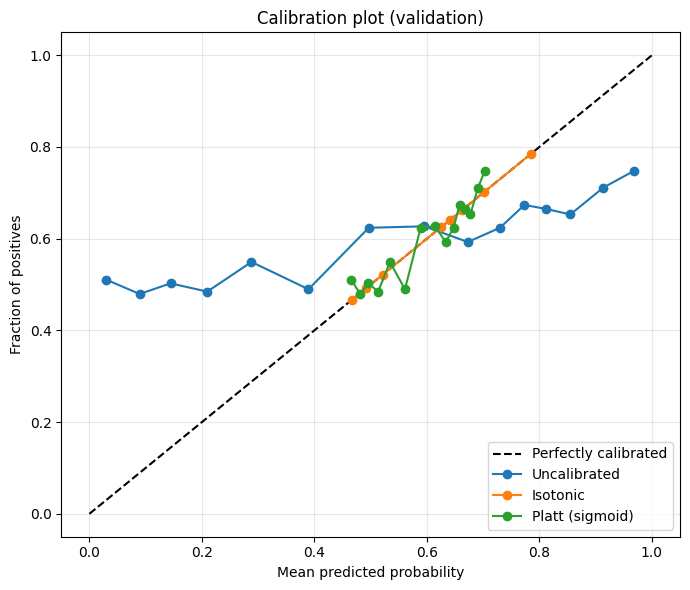

              precision    recall  f1-score   support

    Non-csPC       0.52      0.30      0.38      1175
        csPC       0.63      0.81      0.71      1730

    accuracy                           0.60      2905
   macro avg       0.57      0.55      0.54      2905
weighted avg       0.58      0.60      0.58      2905



In [63]:
# Model Calibration 
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# Aggregate validation labels and probabilities
y_true_val = np.concatenate(true_labels) if isinstance(true_labels, (list, tuple)) else true_labels
y_prob_val = np.concatenate(results_per_fold_der_test)

# Fit calibrators

iso_calibrator = IsotonicRegression(out_of_bounds="clip")
iso_calibrator.fit(y_prob_val, y_true_val)
y_prob_iso = iso_calibrator.transform(y_prob_val)

platt_calibrator = LogisticRegression(solver="lbfgs", max_iter=1000)
platt_calibrator.fit(y_prob_val.reshape(-1, 1), y_true_val)
y_prob_platt = platt_calibrator.predict_proba(y_prob_val.reshape(-1, 1))[:, 1]

# Calibration curves
prob_true_uncal, prob_pred_uncal = calibration_curve(y_true_val, y_prob_val, n_bins=15, strategy="quantile")
prob_true_iso,   prob_pred_iso   = calibration_curve(y_true_val, y_prob_iso, n_bins=15, strategy="quantile")
prob_true_platt, prob_pred_platt = calibration_curve(y_true_val, y_prob_platt, n_bins=15, strategy="quantile")

# Brier scores
brier_uncal = brier_score_loss(y_true_val, y_prob_val)
brier_iso   = brier_score_loss(y_true_val, y_prob_iso)
brier_platt = brier_score_loss(y_true_val, y_prob_platt)
print(f"Brier (uncalibrated): {brier_uncal:.4f}")
print(f"Brier (isotonic):     {brier_iso:.4f}")
print(f"Brier (Platt):        {brier_platt:.4f}")

# Reliability diagram
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.plot(prob_pred_uncal, prob_true_uncal, marker="o", label="Uncalibrated")
plt.plot(prob_pred_iso, prob_true_iso, marker="o", label="Isotonic")
plt.plot(prob_pred_platt, prob_true_platt, marker="o", label="Platt (sigmoid)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration plot (validation)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/results/calibration_curve_bimcv_validation.pdf", dpi=300)
plt.show()

# Helper to apply chosen calibrator to new probabilities
def apply_calibration(probs: np.ndarray, method: str = "isotonic") -> np.ndarray:
    if method == "isotonic":
        return iso_calibrator.transform(np.asarray(probs).ravel())
    elif method == "platt":
        return platt_calibrator.predict_proba(np.asarray(probs).ravel().reshape(-1, 1))[:, 1]
    else:
        raise ValueError("method must be 'isotonic' or 'platt'")
    
# Show metrics on validation set
all_probs_calibrated = apply_calibration(all_probs, method="isotonic")
pred_labels_calibrated = (all_probs_calibrated >= 0.5).astype(int)
report_calibrated = classification_report(all_true, pred_labels_calibrated, target_names=['Non-csPC', 'csPC'])
print(report_calibrated)
    


### Results 5 folds no Derivatives

In [45]:
result_paths_noder = [
    'logs/classification/Prostate_BIMCV_noDerivatives/08-Sep-2025-17:42:38/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/09-Sep-2025-08:52:30/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/10-Sep-2025-08:47:09/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/11-Sep-2025-08:50:30/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/12-Sep-2025-08:45:05/results.json',
]

results_per_fold_noder = []

for path in result_paths_noder:
    with open(path, 'r') as f:
        results = json.load(f)
        results_per_fold_noder.append(np.array(results['Validation Predictions'])[:, 1])  # Probabilities for the positive class



# Read original data
df = pd.read_csv('Files/data_noder.csv')

true_labels = df[df.split=='val']['csPC'].values[:224]
# Repeat true labels for each fold (assuming same validation set)
true_labels = [true_labels for _ in range(len(results_per_fold_noder))]



In [46]:
fig, metrics = plot_mean_roc_cv(true_labels=true_labels, fold_probs=results_per_fold_noder, title="BIMCV(No Derivatives) - Mean ROC Curve with Variability",
                                 out_path="outputs/figures/results/AUC_ROC_BIMCV_no_derivatives.pdf", out_format="pdf")

# Get classification report at 0.5 threshold
reports_per_fold = []
for i, (y_true_f, probs_f) in enumerate(zip(true_labels, results_per_fold_noder), start=1):
    pred_labels_f = (probs_f >= 0.5).astype(int)
    report_f = classification_report(y_true_f, pred_labels_f, target_names=['Non-csPC', 'csPC'])
    print(f"Fold {i} classification report:\n{report_f}\n")
    reports_per_fold.append(report_f)

Fold 1 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.72      0.72      0.72       115
        csPC       0.71      0.71      0.71       109

    accuracy                           0.71       224
   macro avg       0.71      0.71      0.71       224
weighted avg       0.71      0.71      0.71       224


Fold 2 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.72      0.69      0.71       115
        csPC       0.69      0.72      0.71       109

    accuracy                           0.71       224
   macro avg       0.71      0.71      0.71       224
weighted avg       0.71      0.71      0.71       224


Fold 3 classification report:
              precision    recall  f1-score   support

    Non-csPC       0.73      0.71      0.72       115
        csPC       0.71      0.72      0.71       109

    accuracy                           0.72       224
   macro avg       0.72      0.72   

### Results best model

In [2]:
figures_dir = '/home/ceib/jaalzate/BIMCV-Prostate-Classification/outputs/figures/results'
extension = 'png'

In [3]:
# Read results from the json file
results_pretrained_path = 'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/results.json'
results_no_pretrained_path = 'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/results.json'

with open(results_pretrained_path) as f:
    pretrained_results = json.load(f)

with open(results_no_pretrained_path) as f:
    non_pretrained_results = json.load(f)


# Read original data
df = pd.read_csv('Files/data_with_splits_dep_disjoint.csv')

In [9]:
true_labels = df[df.split=='val']['csPC'].values[:400]

pretrained_predictions = np.array(pretrained_results["Validation Predictions"])[:, 1]
non_pretrained_predictions = np.array(non_pretrained_results["Validation Predictions"])[:, 1]


In [10]:
true_labels.shape

(400,)

In [17]:
# Proceed with the analysis using the subset
pretrained_pred_labels = (pretrained_predictions > 0.5).astype(int)
non_pretrained_pred_labels = (non_pretrained_predictions > 0.5).astype(int)

# Classification reports
pretrained_class_report = classification_report(true_labels, pretrained_pred_labels, output_dict=True)
non_pretrained_class_report = classification_report(true_labels, non_pretrained_pred_labels, output_dict=True)

# Confusion matrices
pretrained_conf_matrix = confusion_matrix(true_labels, pretrained_pred_labels)
non_pretrained_conf_matrix = confusion_matrix(true_labels, non_pretrained_pred_labels)

# ROC curves
fpr_pretrained, tpr_pretrained, _ = roc_curve(true_labels, pretrained_predictions)
roc_auc_pretrained = auc(fpr_pretrained, tpr_pretrained)

fpr_non_pretrained, tpr_non_pretrained, _ = roc_curve(true_labels, non_pretrained_predictions)
roc_auc_non_pretrained = auc(fpr_non_pretrained, tpr_non_pretrained)

# Plot ROC curves
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr_pretrained, y=tpr_pretrained,
    mode='lines', name=f'Pre-trained model (AUC = {roc_auc_pretrained:.2f})',
    line=dict(color='darkorange', width=2)
))

fig.add_trace(go.Scatter(
    x=fpr_non_pretrained, y=tpr_non_pretrained,
    mode='lines', name=f'Non-pre-trained model (AUC = {roc_auc_non_pretrained:.2f})',
    line=dict(color='blue', width=2)
))

fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines', name='Random Chance',
    line=dict(color='navy', width=2, dash='dash')
))

fig.update_layout(
    #title='Receiver Operating Characteristic (ROC) Curve',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    legend=dict(x=0.4, y=0.1),
    width=800, height=600,
    font=dict(size=16),
    margin=dict(l=50, r=50, t=50, b=50),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')

fig.show()
fig.write_image(os.path.join(figures_dir,"AUC_ROC_BIMCV."+extension),scale=6)

# Generate precision-recall curves
precision_pretrained, recall_pretrained, _ = precision_recall_curve(true_labels, pretrained_predictions)
auc_precision_recall_pretrained = auc(recall_pretrained, precision_pretrained)

precision_non_pretrained, recall_non_pretrained, _ = precision_recall_curve(true_labels, non_pretrained_predictions)
auc_precision_recall_non_pretrained = auc(recall_non_pretrained, precision_non_pretrained)

# Create the precision-recall curve plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recall_pretrained, y=precision_pretrained,
    mode='lines', name=f'Pre-trained model (AUC = {auc_precision_recall_pretrained:.2f})',
    line=dict(color='darkorange', width=2)
))

fig.add_trace(go.Scatter(
    x=recall_non_pretrained, y=precision_non_pretrained,
    mode='lines', name=f'Non-pre-trained model (AUC = {auc_precision_recall_non_pretrained:.2f})',
    line=dict(color='blue', width=2)
))

fig.update_layout(
    #title='Precision-Recall Curve',
    xaxis_title='Recall',
    yaxis_title='Precision',
    legend=dict(x=0.4, y=0.1),
    width=800, height=600,
    font=dict(size=16),
    margin=dict(l=50, r=50, t=50, b=50),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')

fig.show()
fig.write_image(os.path.join(figures_dir,"Precision_Recall_BIMCV."+extension),scale=6)

RuntimeError: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome



In [12]:
# Convert classification report dictionaries to dataframes for better readability
pretrained_class_report_df = pd.DataFrame(pretrained_class_report).transpose()
non_pretrained_class_report_df = pd.DataFrame(non_pretrained_class_report).transpose()

# Display the classification reports
print("pre-trained model classification report:")
display(pretrained_class_report_df)

print("non-pre-trained model classification report:")
display(non_pretrained_class_report_df)

pre-trained model classification report:


,precision,recall,f1-score,support
0.0,0.730769,0.718919,0.724796,185.0000
1.0,0.761468,0.772093,0.766744,215.0000
accuracy,0.747500,0.747500,0.747500,0.7475
macro avg,0.746119,0.745506,0.745770,400.0000
weighted avg,0.747270,0.747500,0.747343,400.0000


non-pre-trained model classification report:


,precision,recall,f1-score,support
0.0,0.770701,0.654054,0.707602,185.00
1.0,0.736626,0.832558,0.781659,215.00
accuracy,0.750000,0.750000,0.750000,0.75
macro avg,0.753663,0.743306,0.744631,400.00
weighted avg,0.752385,0.750000,0.747408,400.00


In [8]:
#print confusion matrices
print("pre-trained model confusion matrix:")
print(pretrained_conf_matrix)

print("non-pre-trained model confusion matrix:")
print(non_pretrained_conf_matrix)

pre-trained model confusion matrix:
[[72 33]
 [23 80]]
non-pre-trained model confusion matrix:
[[82 23]
 [41 62]]


## PICAI Results

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, RocCurveDisplay
import numpy as np
import plotly.graph_objects as go
import os

In [3]:
df = pd.read_csv('/home/ceib/jaalzate/BIMCV-Prostate-Classification/Files/picai_cv.csv')

In [4]:
# Path to the JSON file
json_path = '/home/ceib/jaalzate/BIMCV-Prostate-Classification/logs/classification/Prostate_Picai_efficientnetb7/18-Aug-2025-10:41:51/cross_val_results.json'

# Load JSON data
with open(json_path) as f:
    cross_val_results = json.load(f)

# Extract test predictions and true labels
test_predictions = []
true_labels = []
for i, (fold, data) in enumerate(cross_val_results.items()):
    if 'Test Predictions' in data:
        test_predictions.append(np.array(data['Test Predictions'])[:, 1])
        true_labels.append(df[df[f"Fold {i}"] == 'test']['label'].values[:len(data['Test Predictions'])])

# Convert to numpy arrays
test_predictions = np.array(test_predictions)  # Probability of the positive class
true_labels = np.array(true_labels)

In [5]:
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc


tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

for fold, (y_true, y_pred) in enumerate(zip(true_labels, test_predictions)):

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Calculate the mean and standard deviation of the TPRs
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# Create the plotly figure
fig = go.Figure()

# Add each fold's ROC curve
for i, (tpr, auc_val) in enumerate(zip(tprs, aucs)):
    fig.add_trace(go.Scatter(
        x=mean_fpr, y=tpr,
        mode='lines',
        line=dict(width=1),
        name=f'ROC fold {i} (AUC = {auc_val:.2f})',
        opacity=0.3
    ))

# Add the mean ROC curve
fig.add_trace(go.Scatter(
    x=mean_fpr, y=mean_tpr,
    mode='lines',
    line=dict(color='blue', width=2),
    name=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})'
))

# Add the standard deviation fill
fig.add_trace(go.Scatter(
    x=np.concatenate([mean_fpr, mean_fpr[::-1]]),
    y=np.concatenate([tprs_upper, tprs_lower[::-1]]),
    fill='toself',
    fillcolor='rgba(128, 128, 128, 0.2)',
    line=dict(color='rgba(255, 255, 255, 0)'),
    hoverinfo="skip",
    showlegend=True,
    name='± 1 std. dev.'
))

# Add the chance line
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='black', dash='dash'),
    name='Chance level (AUC = 0.5)'
))

# Update layout
fig.update_layout(
    title=dict(text='Mean ROC Curve with Variability', x=0.5),
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    legend=dict(x=0.6, y=0.05),
    width=800, height=600,
    #font=dict(family="Times New Roman", size=16),
    margin=dict(l=50, r=50, t=50, b=50),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

# Add grid lines and adjust axes
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')

# Show plot
fig.show()
fig.write_image(os.path.join(figures_dir,"AUC_ROC_Picai."+extension),scale=6)

NameError: name 'figures_dir' is not defined

In [6]:
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve, auc


precisions = []
aucs = []
mean_recall = np.linspace(0, 1, 100)

# Simulate multiple folds for the example
for fold, (y_true, y_pred) in enumerate(zip(true_labels, test_predictions)):

    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    pr_auc = auc(recall, precision)
    aucs.append(pr_auc)

    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_precision)

# Calculate the mean and standard deviation of the precisions
mean_precision = np.mean(precisions, axis=0)
mean_auc = auc(mean_recall, mean_precision)
std_auc = np.std(aucs)

std_precision = np.std(precisions, axis=0)
precisions_upper = np.minimum(mean_precision + std_precision, 1)
precisions_lower = np.maximum(mean_precision - std_precision, 0)

# Create the plotly figure
fig = go.Figure()

# Add each fold's Precision-Recall curve
for i, (precision, auc_val) in enumerate(zip(precisions, aucs)):
    fig.add_trace(go.Scatter(
        x=mean_recall, y=precision,
        mode='lines',
        line=dict(width=1),
        name=f'PR fold {i} (AUC = {auc_val:.2f})',
        opacity=0.3
    ))

# Add the mean Precision-Recall curve
fig.add_trace(go.Scatter(
    x=mean_recall, y=mean_precision,
    mode='lines',
    line=dict(color='blue', width=2),
    name=f'Mean PR (AUC = {mean_auc:.2f} ± {std_auc:.2f})'
))

# Add the standard deviation fill
fig.add_trace(go.Scatter(
    x=np.concatenate([mean_recall, mean_recall[::-1]]),
    y=np.concatenate([precisions_upper, precisions_lower[::-1]]),
    fill='toself',
    fillcolor='rgba(128, 128, 128, 0.2)',
    line=dict(color='rgba(255, 255, 255, 0)'),
    hoverinfo="skip",
    showlegend=True,
    name='± 1 std. dev.'
))

# Update layout
fig.update_layout(
    title=dict(text='Mean Precision-Recall Curve with Variability', x=0.5),
    xaxis_title='Recall',
    yaxis_title='Precision',
    legend=dict(x=0.6, y=1),
    width=800, height=600,
    font=dict(size=16),
    margin=dict(l=50, r=50, t=50, b=50),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

# Add grid lines and adjust axes
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')

# Show plot
fig.show()
fig.write_image(os.path.join(figures_dir,"Precision_Recall_Picai."+extension),scale=6)

NameError: name 'figures_dir' is not defined

# Evaluating PICAI with pretrained model

In [19]:
from Prostate_Cancer_TFM.Classification.Dataloader_Picai import Dataloader
from Prostate_Cancer_TFM.Classification.models import EfficientNet_pretrained
import torch
import torchmetrics
import torch.nn.functional as F


 missing cuda symbols while dynamic loading
 cuFile initialization failed


In [20]:
dataloader = Dataloader(path='Prostate_Cancer_TFM/Files/PICAI/partition_1_cv.csv',partition_column="Fold 2")
test_dataloader = dataloader(partition='test')

Loading dataset: 100%|██████████| 298/298 [00:26<00:00, 11.39it/s]


In [18]:
pretrained_weights_path = 'Prostate_Cancer_TFM/Classification/logs/classification/Prostate/05-Jul-2024-10:48:50/models/best-model-weights.pth'
model = EfficientNet_pretrained(model_name = "efficientnet-b7",
                                n_classes = 2, 
                                in_channels_eff = 3,
                                pretrained_weights_path = None)

model.load_state_dict(torch.load(pretrained_weights_path)["state_dict"])

<All keys matched successfully>

In [138]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # Set the model to evaluation mode

y_pred_picai = []
y_true_picai = []

for data in test_dataloader:
    image, label = data['image'], data['label']
    image = image.to(device)
    label = label.to(device)

    with torch.no_grad():  # Disable gradient calculation for inference
        outputs = model(image)
        probabilities = F.softmax(outputs, dim=1)  # Apply softmax to get probabilities

    y_pred_picai.extend(probabilities.cpu().numpy())
    y_true_picai.extend(label.cpu().numpy())

# Convert lists to numpy arrays for further processing
y_pred_picai = np.array(y_pred_picai)
y_true_picai = np.array(y_true_picai)

In [150]:
pretrained_predictions = y_pred_picai[:288,1]
non_pretrained_predictions = test_predictions[2]
true_labels = true_labels[2]
# Proceed with the analysis using the subset
pretrained_pred_labels = (pretrained_predictions > 0.5).astype(int)
non_pretrained_pred_labels = (non_pretrained_predictions > 0.5).astype(int)

# Classification reports
pretrained_class_report = classification_report(true_labels, pretrained_pred_labels, output_dict=True)
non_pretrained_class_report = classification_report(true_labels, non_pretrained_pred_labels, output_dict=True)

# Confusion matrices
pretrained_conf_matrix = confusion_matrix(true_labels, pretrained_pred_labels)
non_pretrained_conf_matrix = confusion_matrix(true_labels, non_pretrained_pred_labels)

# ROC curves
fpr_pretrained, tpr_pretrained, _ = roc_curve(true_labels, pretrained_predictions)
roc_auc_pretrained = auc(fpr_pretrained, tpr_pretrained)

fpr_non_pretrained, tpr_non_pretrained, _ = roc_curve(true_labels, non_pretrained_predictions)
roc_auc_non_pretrained = auc(fpr_non_pretrained, tpr_non_pretrained)

# Plot ROC curves
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr_pretrained, y=tpr_pretrained,
    mode='lines', name=f'Pre-trained model (AUC = {roc_auc_pretrained:.2f})',
    line=dict(color='darkorange', width=2)
))

fig.add_trace(go.Scatter(
    x=fpr_non_pretrained, y=tpr_non_pretrained,
    mode='lines', name=f'Non-pre-trained model (AUC = {roc_auc_non_pretrained:.2f})',
    line=dict(color='blue', width=2)
))

fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines', name='Random Chance',
    line=dict(color='navy', width=2, dash='dash')
))

fig.update_layout(
    title='Receiver Operating Characteristic (ROC) Curve',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    legend=dict(x=0.4, y=0.1),
    width=800, height=600,
    font=dict(size=16),
    margin=dict(l=50, r=50, t=50, b=50),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')

fig.show()

# Generate precision-recall curves
precision_pretrained, recall_pretrained, _ = precision_recall_curve(true_labels, pretrained_predictions)
auc_precision_recall_pretrained = auc(recall_pretrained, precision_pretrained)

precision_non_pretrained, recall_non_pretrained, _ = precision_recall_curve(true_labels, non_pretrained_predictions)
auc_precision_recall_non_pretrained = auc(recall_non_pretrained, precision_non_pretrained)

# Create the precision-recall curve plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recall_pretrained, y=precision_pretrained,
    mode='lines', name=f'Pre-trained model (AUC = {auc_precision_recall_pretrained:.2f})',
    line=dict(color='darkorange', width=2)
))

fig.add_trace(go.Scatter(
    x=recall_non_pretrained, y=precision_non_pretrained,
    mode='lines', name=f'Non-pre-trained model (AUC = {auc_precision_recall_non_pretrained:.2f})',
    line=dict(color='blue', width=2)
))

fig.update_layout(
    title='Precision-Recall Curve',
    xaxis_title='Recall',
    yaxis_title='Precision',
    legend=dict(x=0.4, y=0.1),
    width=800, height=600,
    font=dict(size=16),
    margin=dict(l=50, r=50, t=50, b=50),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=True, zerolinewidth=1, zerolinecolor='lightgray')

fig.show()

# Model Interpretation

In [20]:
from bimcv_prostate.data.dataloaders import ProstateImageDataLoader as Dataloader
from models import EfficientNet_pretrained
import torch
import torchmetrics
import torch.nn.functional as F
import monai
from tqdm import tqdm
import os

In [21]:
dataloader = Dataloader(path='Files/data_with_splits_dep_disjoint.csv')
test_dataloader = dataloader(partition='val')

Loading dataset: 100%|██████████| 404/404 [02:20<00:00,  2.88it/s]


In [12]:
pretrained_weights_path = '/home/ceib/jaalzate/BIMCV-Prostate-Classification/logs/classification/Prostate_BIMCV/20-Aug-2025-12:11:05/models/best-model-weights.pth'
model = EfficientNet_pretrained(model_name = "efficientnet-b7",
                                n_classes = 2, 
                                in_channels_eff = 3,
                                pretrained_weights_path = None)

model.load_state_dict(torch.load(pretrained_weights_path)["state_dict"])

<All keys matched successfully>

In [22]:
model_paths_pretrained = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/models/best-model-weights.pth',
]

no_pretrained_path = 'logs/classification/Prostate_BIMCV_no_pretrained/15-Sep-2025-14:51:00/models/best-model-weights.pth'

models_pretrained = [load_model(p) for p in model_paths_pretrained]
no_pretrained_model = load_model(no_pretrained_path)

odict_keys(['model._conv_stem.weight', 'model._bn0.weight', 'model._bn0.bias', 'model._bn0.running_mean', 'model._bn0.running_var', 'model._bn0.num_batches_tracked', 'model._blocks.0.0._depthwise_conv.weight', 'model._blocks.0.0._bn1.weight', 'model._blocks.0.0._bn1.bias', 'model._blocks.0.0._bn1.running_mean', 'model._blocks.0.0._bn1.running_var', 'model._blocks.0.0._bn1.num_batches_tracked', 'model._blocks.0.0._se_reduce.weight', 'model._blocks.0.0._se_reduce.bias', 'model._blocks.0.0._se_expand.weight', 'model._blocks.0.0._se_expand.bias', 'model._blocks.0.0._project_conv.weight', 'model._blocks.0.0._bn2.weight', 'model._blocks.0.0._bn2.bias', 'model._blocks.0.0._bn2.running_mean', 'model._blocks.0.0._bn2.running_var', 'model._blocks.0.0._bn2.num_batches_tracked', 'model._blocks.0.1._depthwise_conv.weight', 'model._blocks.0.1._bn1.weight', 'model._blocks.0.1._bn1.bias', 'model._blocks.0.1._bn1.running_mean', 'model._blocks.0.1._bn1.running_var', 'model._blocks.0.1._bn1.num_batches_t

In [23]:
def get_next_im(loader):
    test_data = next(iter(loader))
    #print(test_data["image_meta_dict"]["filename_or_obj"])
    return test_data["image"].to(device), test_data["label"].to(device)


def plot_occlusion_heatmap(im, heatmap):
    plt.subplots(1, 2)
    plt.subplot(1, 2, 1)
    plt.imshow(np.squeeze(im.cpu()))
    plt.colorbar()
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap)
    plt.colorbar()
    plt.show()

In [24]:
results = [torch.zeros((3, 128, 128, 32)), torch.zeros((3, 128, 128, 32))]
counts = [0, 0]

In [343]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models_pretrained[0]
model.to(device)
model.eval()

occ_sens = monai.visualize.OcclusionSensitivity(nn_module=model, mask_size=8, n_batch=64, verbose=True, mode = 'mean_patch')

with torch.no_grad():
    idx=np.random.randint(0,len(test_dataloader))
    img, label = (test_dataloader.dataset[idx]['image'].to(device),test_dataloader.dataset[idx]['label'])
    print(img.shape)
    pred_label = torch.nn.functional.softmax(model(img.unsqueeze(0)), dim=1).argmax().item()
    print(f"Prediction {pred_label}")
    print(f"Label {label.argmax().item()}")
    label = label.argmax().item()
    heatmap = occ_sens(x=img.unsqueeze(0))

torch.Size([3, 128, 128, 32])
Prediction 1
Label 1


100%|██████████| 35/35 [00:10<00:00,  3.48it/s]


In [344]:
heatmap[1].shape

torch.Size([1, 1, 128, 128, 32])

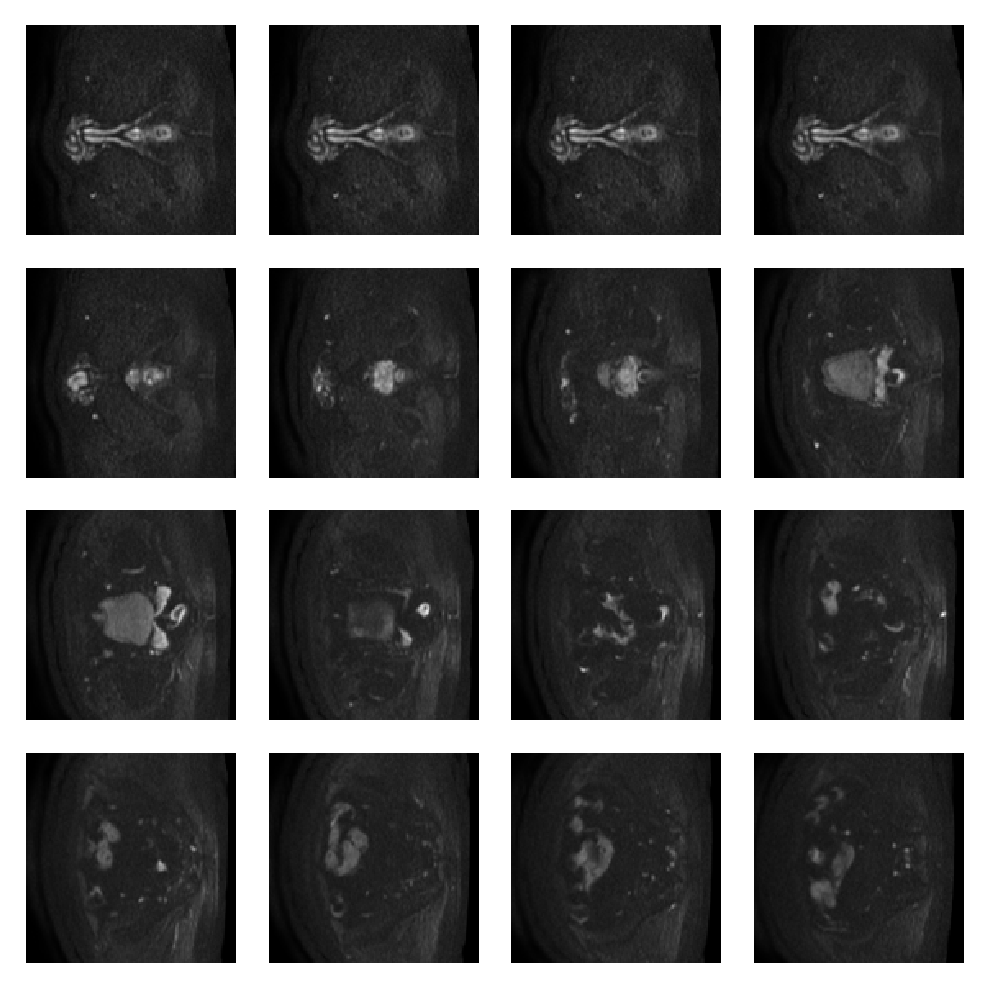

In [345]:
monai.visualize.matshow3d(volume=img.cpu()[1:2], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False,cmap='gray')
plt.show()

In [346]:
heatmap[0][0, 0:1].shape

torch.Size([1, 128, 128, 32])

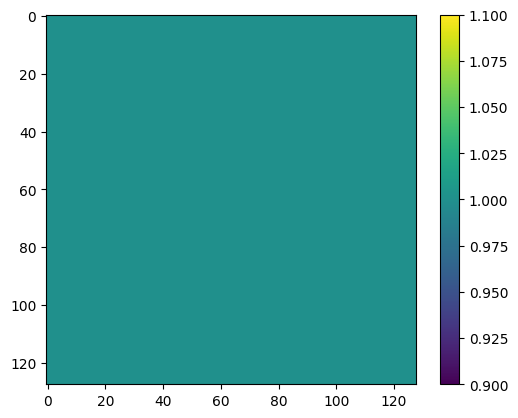

In [347]:
plt.imshow(np.squeeze(heatmap[1][...,18]))
plt.colorbar()
plt.show()

In [348]:
norm_heatmap = (heatmap[0][:, 1:2] - heatmap[0][:, 1:2].min()) / (heatmap[0][:, 1:2].max() - heatmap[0][:, 1:2].min())


In [349]:
norm_heatmap.shape

torch.Size([1, 1, 128, 128, 32])

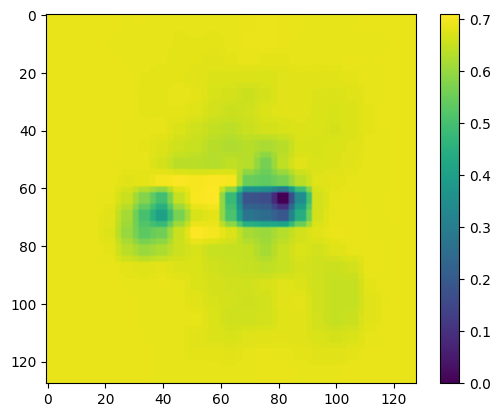

In [350]:
plt.imshow(np.squeeze(norm_heatmap[...,2]))
plt.colorbar()
plt.show()

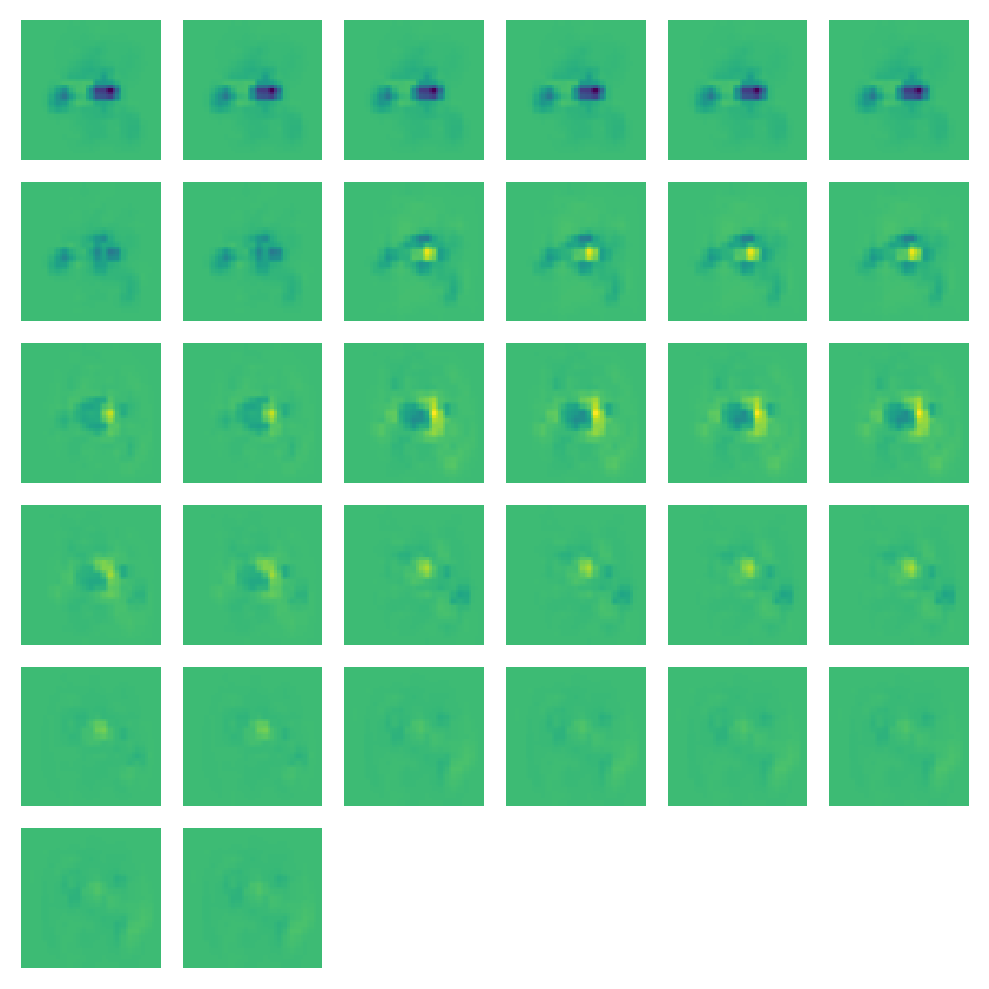

In [351]:
monai.visualize.matshow3d(volume=norm_heatmap, frame_dim=-1, channel_dim=1, every_n=1, margin=10, show=False)
plt.show()

In [352]:
heatmap[1].min(), heatmap[1].max()

(metatensor(1, device='cuda:0'), metatensor(1, device='cuda:0'))

In [353]:
heatmap[0].shape

torch.Size([1, 2, 128, 128, 32])

In [354]:
pp_class = heatmap[0].argmax(dim=1)

In [355]:
pp_class.min(), pp_class.max()

(metatensor(1, device='cuda:0'), metatensor(1, device='cuda:0'))

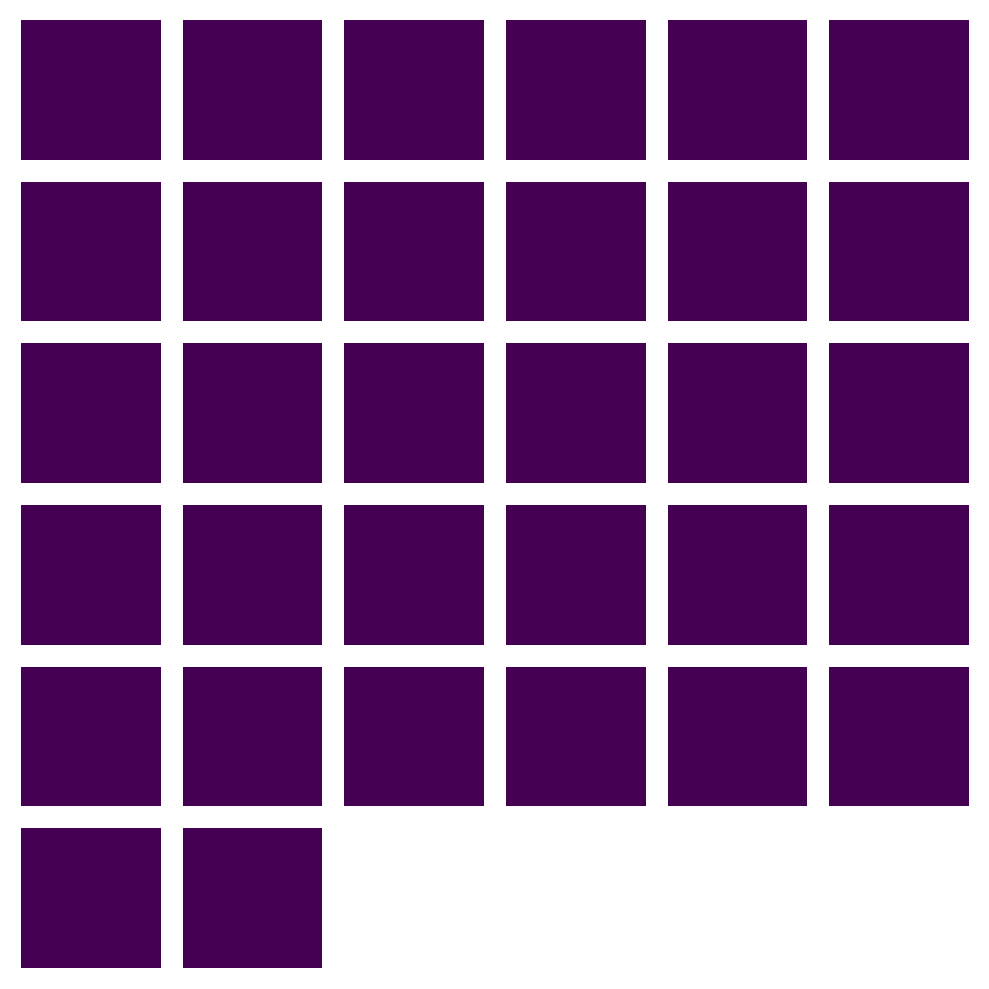

In [356]:
monai.visualize.matshow3d(volume=heatmap[1], frame_dim=-1, channel_dim=1, every_n=1, margin=10, show=False)
plt.show()

In [357]:
img.cpu()[1:2].shape

torch.Size([1, 128, 128, 32])

In [358]:
norm_heatmap.shape

torch.Size([1, 1, 128, 128, 32])

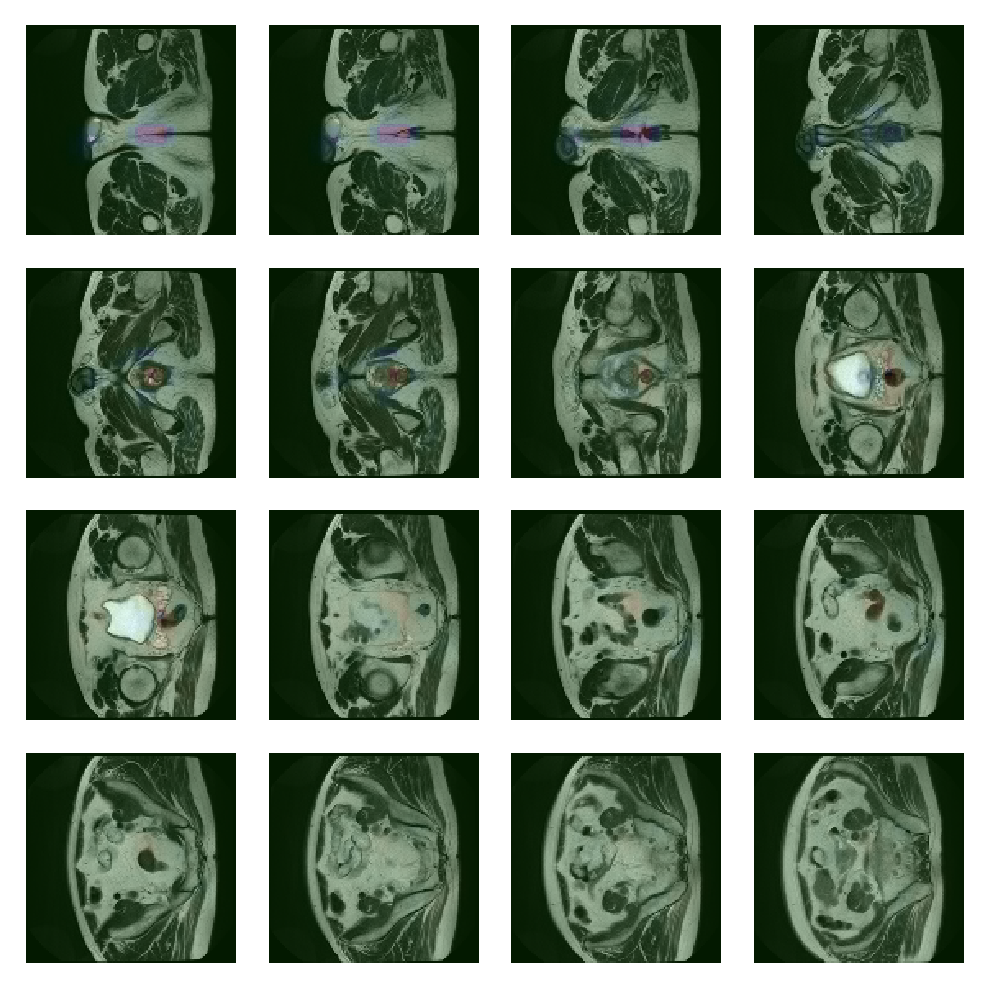

In [360]:
blended = monai.visualize.utils.blend_images(255*img.cpu()[0:1], 
                                                255*(1-norm_heatmap[0].cpu()), 
                                                alpha=0.1,
                                                transparent_background=True)
monai.visualize.matshow3d(volume=blended, frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
plt.show()

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

occ_sens = monai.visualize.OcclusionSensitivity(nn_module=model, mask_size=8, n_batch=64, verbose=False)
with torch.no_grad():    
    for data in tqdm(test_dataloader):
        img, label = data["image"].to(device), data["label"].to(device)
        pred_label = torch.nn.functional.softmax(model(img), dim=1).argmax().item()
        label = label.argmax().item()
        if label == pred_label:
            occ_result, _ = occ_sens(x=img)
            occ_result = occ_result[0, label][None]
            torch.save(occ_result.cpu(), f"outputs/results/sensitivity_maps/class{label}_{os.path.basename(img.meta['filename_or_obj'][0])}")
            results[label] += occ_result.cpu()
            counts[label] += 1

NameError: name 'model' is not defined

In [181]:
no_csPCa = results[0] / counts[0]

In [182]:
csPCa = results[1] / counts[1]

In [184]:
torch.save({"no_csPCa": no_csPCa, "csPCa": csPCa}, "Prostate_Cancer_TFM/Classification/Prostate_Cancer_heatmaps_BIMCV.pth")

In [678]:
maps = torch.load("Prostate_Cancer_TFM/Classification/Prostate_Cancer_heatmaps_BIMCV.pth")

## GradCAM + Guided BackPropagation

torch.Size([3, 128, 128, 32])
Prediction 1
Label tensor([0., 1.])


Computing GuidedBackpropSmoothGrad: 100%|██████████| 50/50 [00:07<00:00,  6.51it/s]


torch.Size([3, 128, 128, 32])


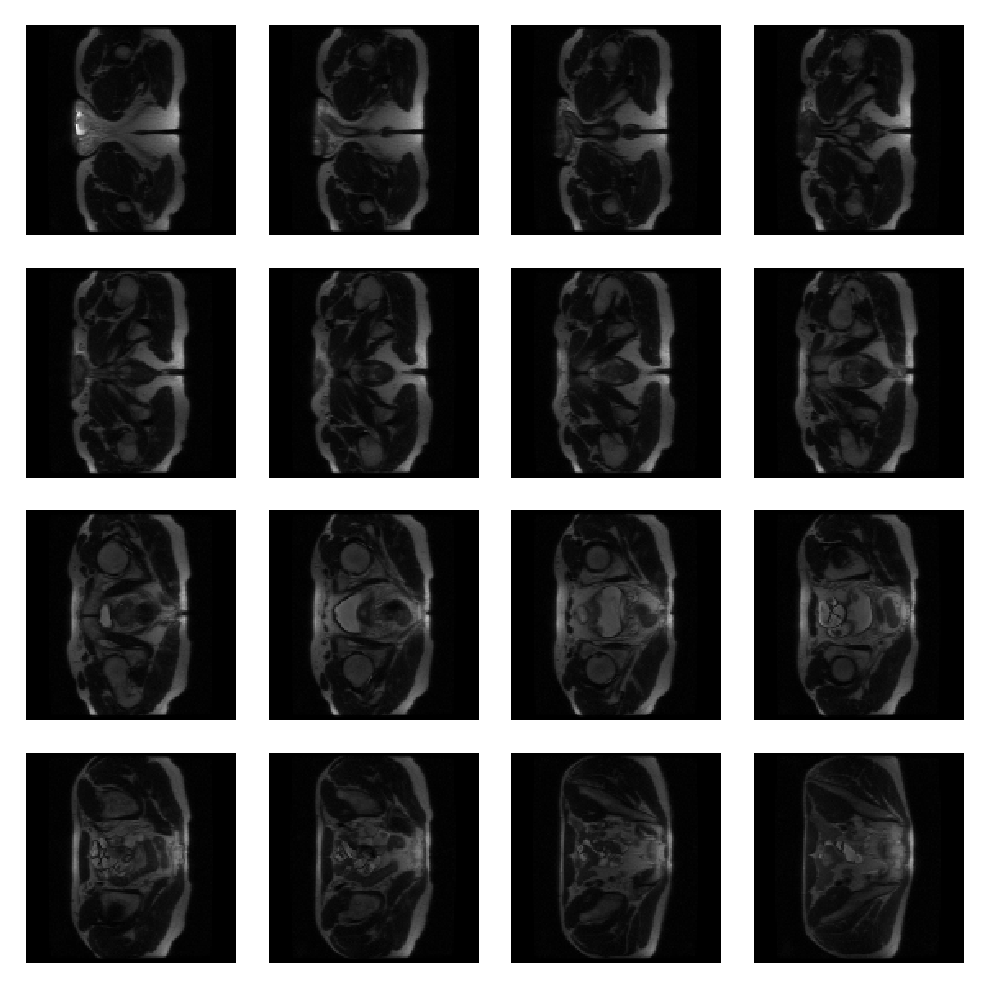

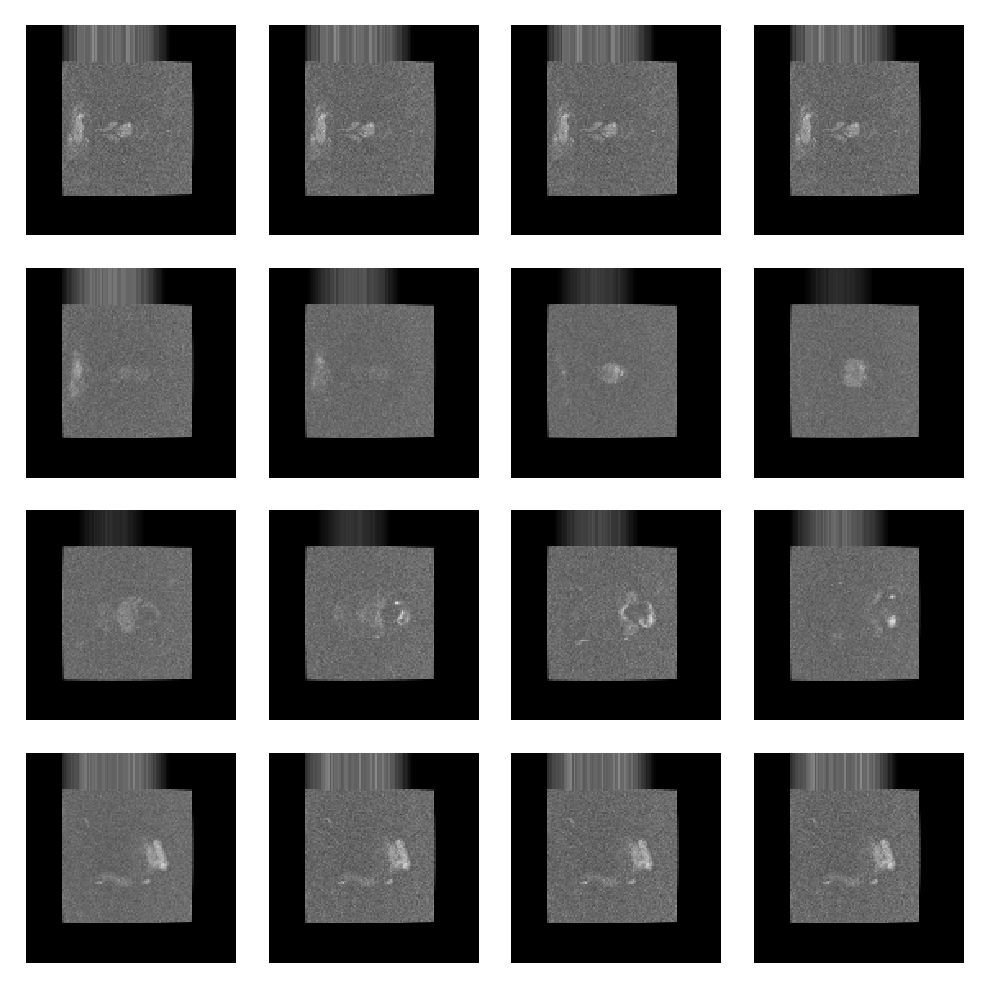

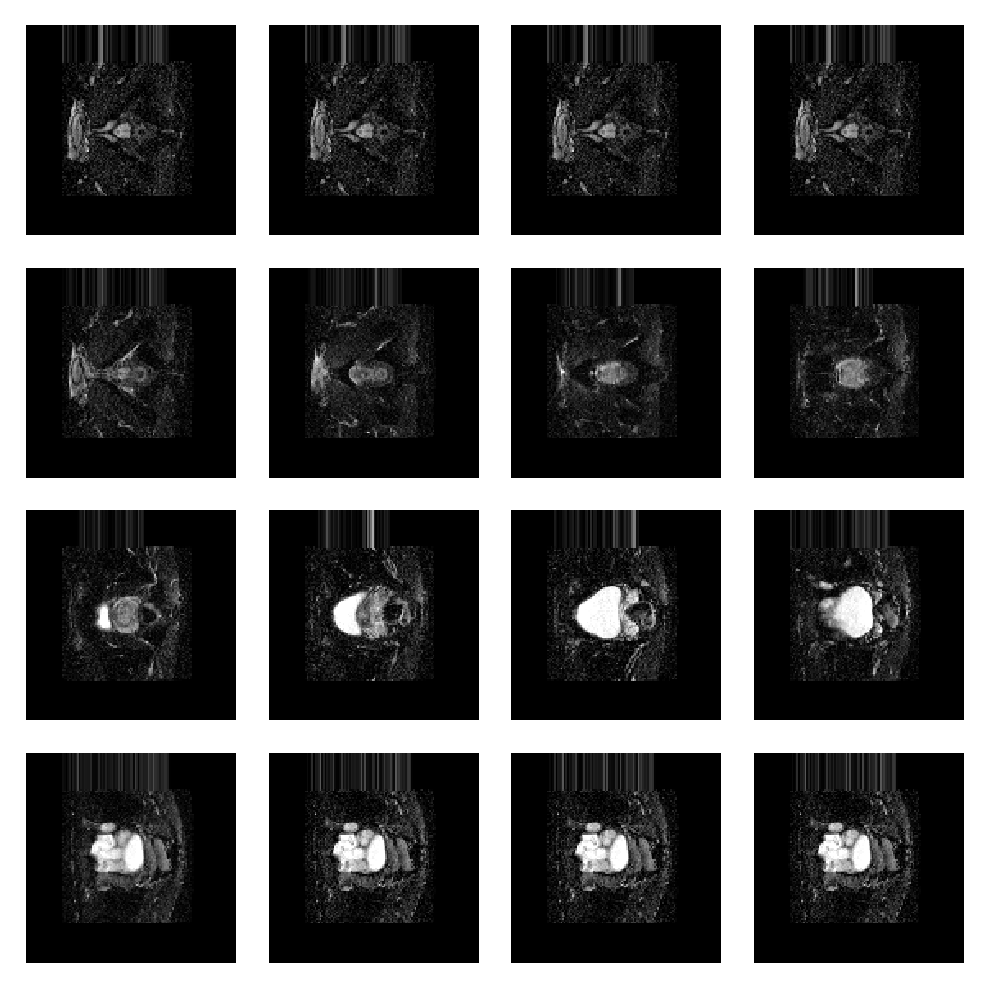

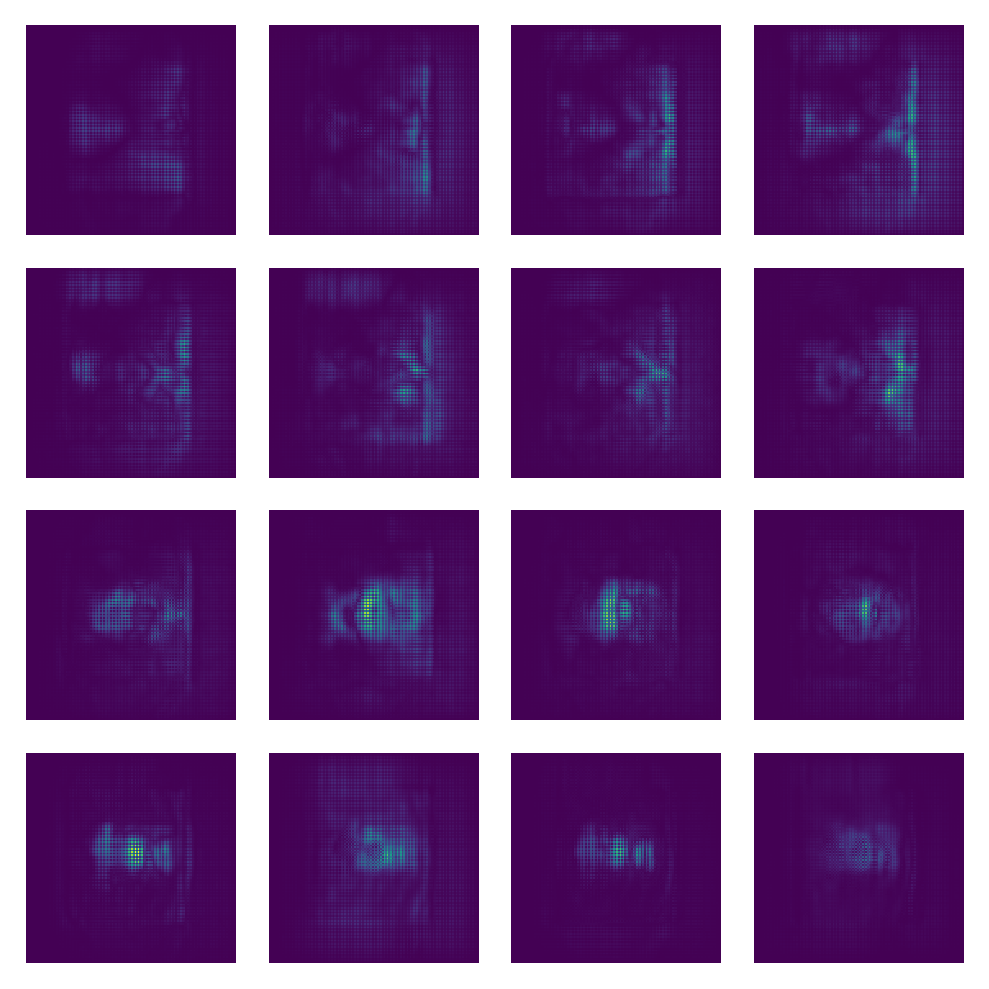

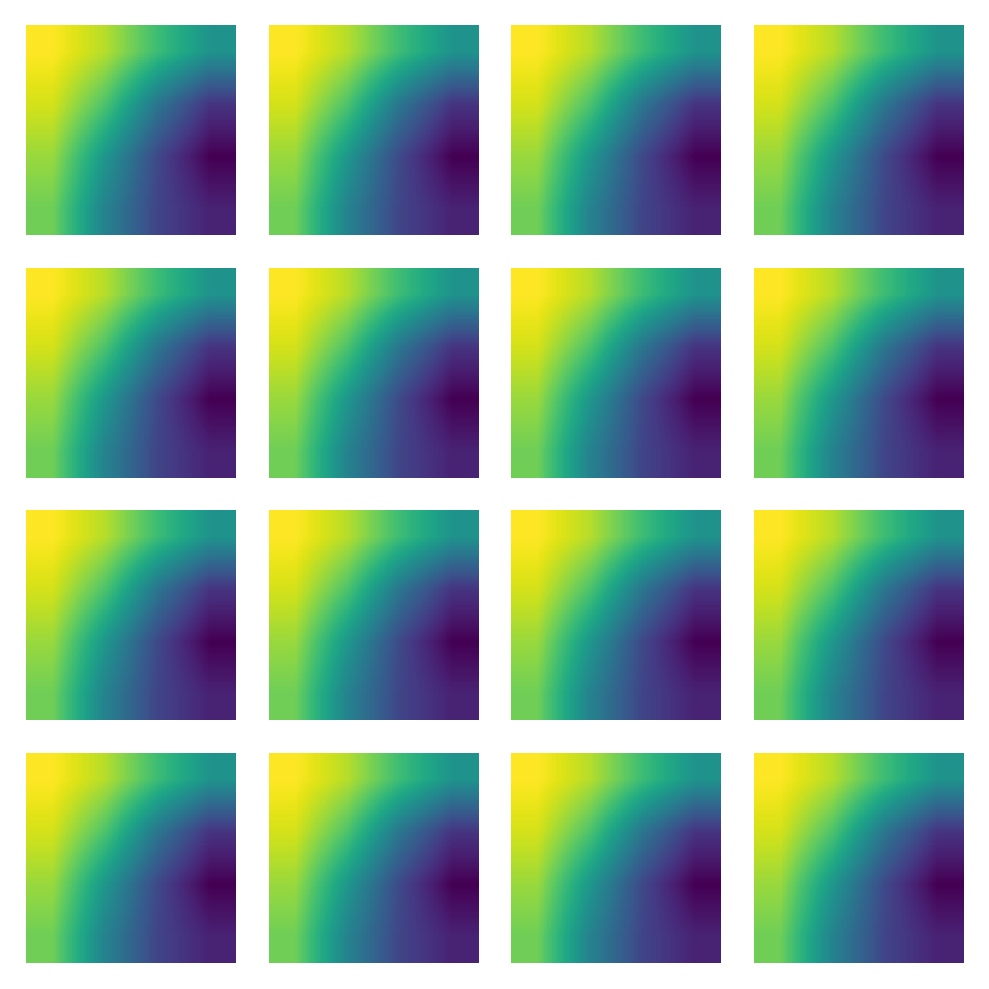

WARNING	matplotlib.image:image.py:_normalize_image_array()- Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


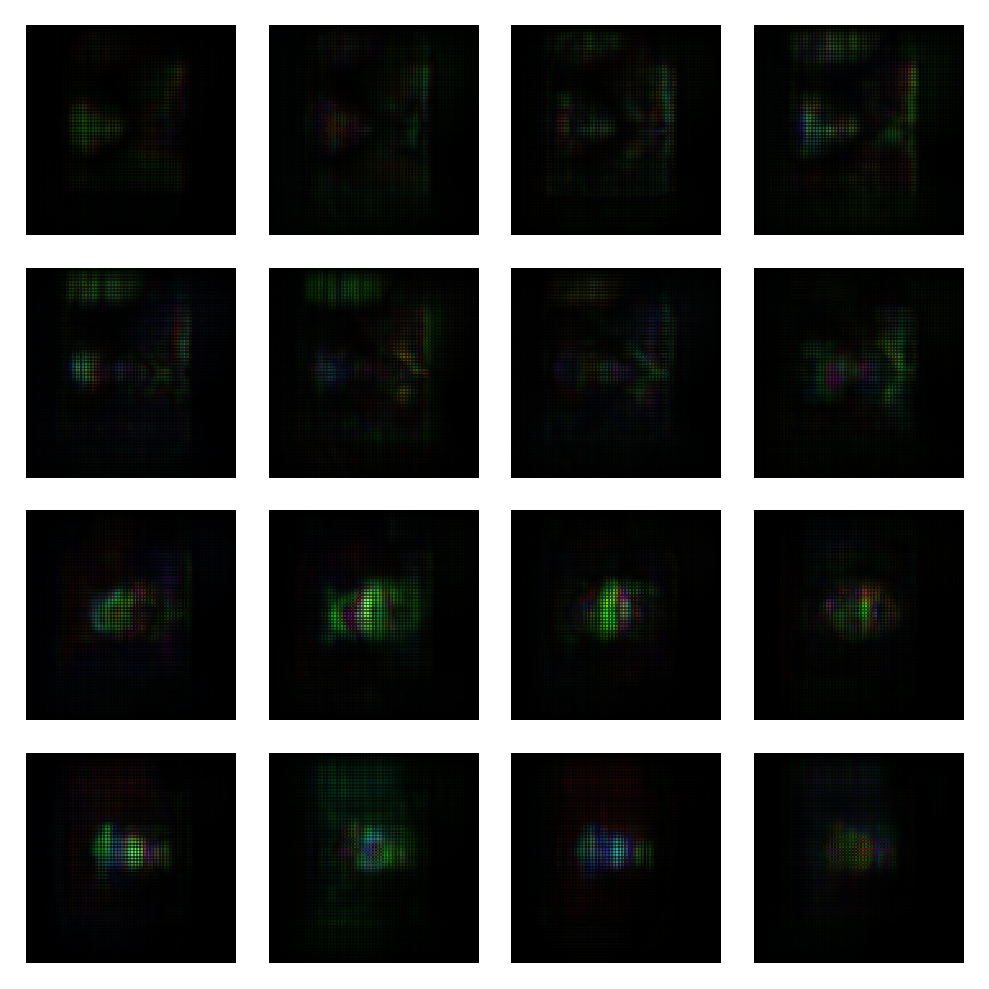

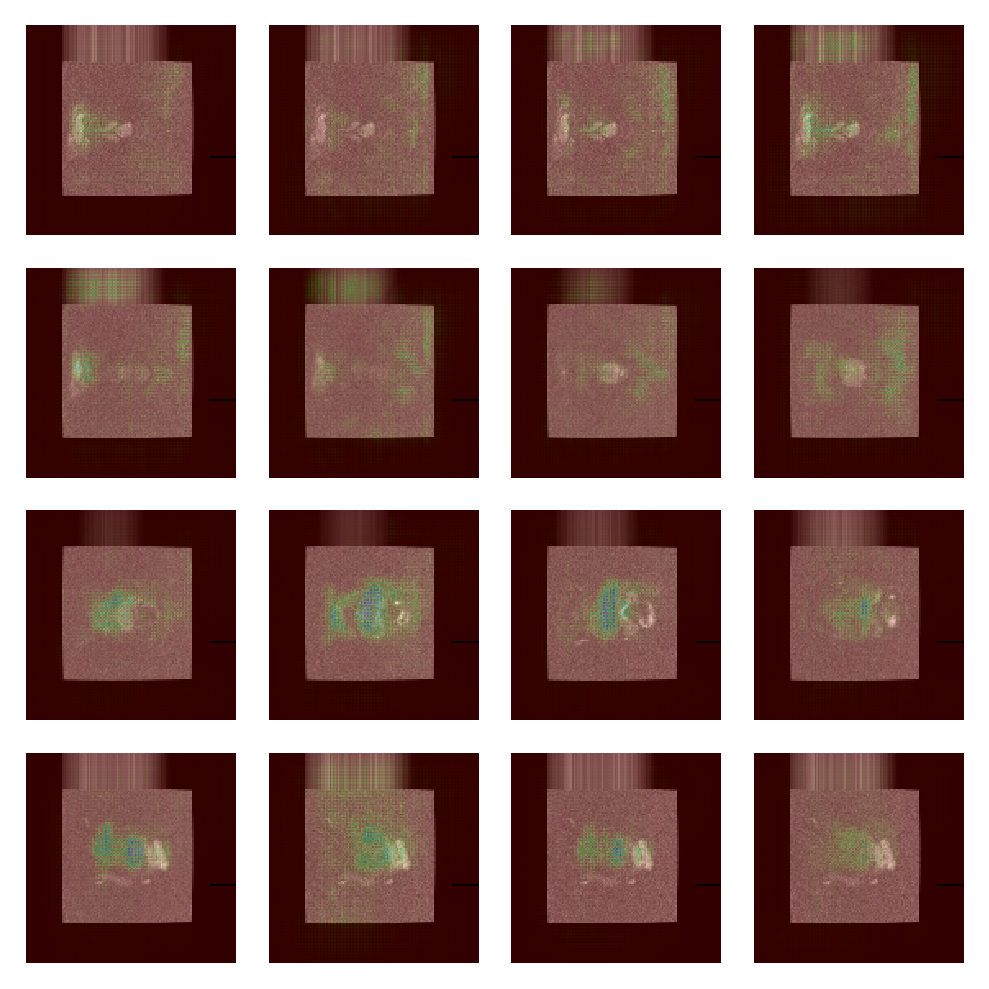

In [329]:
# Testing GradCAM
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
#model.requires_grad_=True
cam = monai.visualize.class_activation_maps.CAM(nn_module=model, target_layers="model._conv_head", fc_layers="model._fc")
gbp = monai.visualize.gradient_based.GuidedBackpropSmoothGrad(model,n_samples=50)
#with torch.no_grad():    

idx=np.random.randint(0,len(test_dataloader))
img, label = (test_dataloader.dataset[idx]['image'].to(device),test_dataloader.dataset[idx]['label'])
print(img.shape)
pred_label = torch.nn.functional.softmax(model(img.unsqueeze(0)), dim=1).argmax().item()
print(f"Prediction {pred_label}")
print(f"Label {label}")
label = label.argmax().item()
if label == pred_label:
    cam_result = cam(x=img.unsqueeze(0)).squeeze(0).cpu()
    gbp_result = gbp(x=img.unsqueeze(0)).squeeze(0).cpu()
    
    gbp_result = 255*(gbp_result - gbp_result.min())/(gbp_result.max() - gbp_result.min())
    cam_result = 255*(cam_result - cam_result.min())/(cam_result.max() - cam_result.min())
    
    # cam_result = torch.where(cam_result.cpu() > 0.9, cam_result.cpu(), 0)
    # gbp_result = torch.where(gbp_result.cpu() < 0.3, gbp_result.cpu(), 1)
    
    #gbp_result = 255*(gbp_result - gbp_result.min())/(gbp_result.max() - gbp_result.min())
    # cam_result = 255*(cam_result - cam_result.min())/(cam_result.max() - cam_result.min())

    #Revert gpb probabilities where 1 is the max
    

    result = cam_result * gbp_result

    print(result.shape)
    
    result = (result - result.min())/(result.max() - result.min())
    #result = 255*torch.where(result.cpu() > 0.9, result.cpu(), 0)

    # Plot the GradCAM result
    blended = monai.visualize.utils.blend_images(255*img.cpu()[1:2], 
                                                result[1:2], 
                                                alpha=0.2,
                                                transparent_background=True)
    
    #crop images

    #Image T2w
    monai.visualize.matshow3d(volume=img.cpu()[0:1], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False,cmap='gray')
    plt.show()

    #Image ADC
    monai.visualize.matshow3d(volume=img.cpu()[1:2], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False,cmap='gray')
    plt.show()

    #Image BVAL
    monai.visualize.matshow3d(volume=img.cpu()[2:3], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False,cmap='gray')
    plt.show()

    #gpb Result
    monai.visualize.matshow3d(volume=gbp_result[1:2], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
    plt.show()
    
    #cam Result
    monai.visualize.matshow3d(volume=cam_result, frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
    plt.show()

    #Complete Result
    monai.visualize.matshow3d(volume=result, frame_dim=-1, channel_dim=0, every_n=2, margin=10, fill_value=255, show=False, cmap = 'gray')
    plt.show()

    #Blended Result
    monai.visualize.matshow3d(volume=blended, frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
    plt.show()

Idx 45 | True class: 1 | Pred class: 1


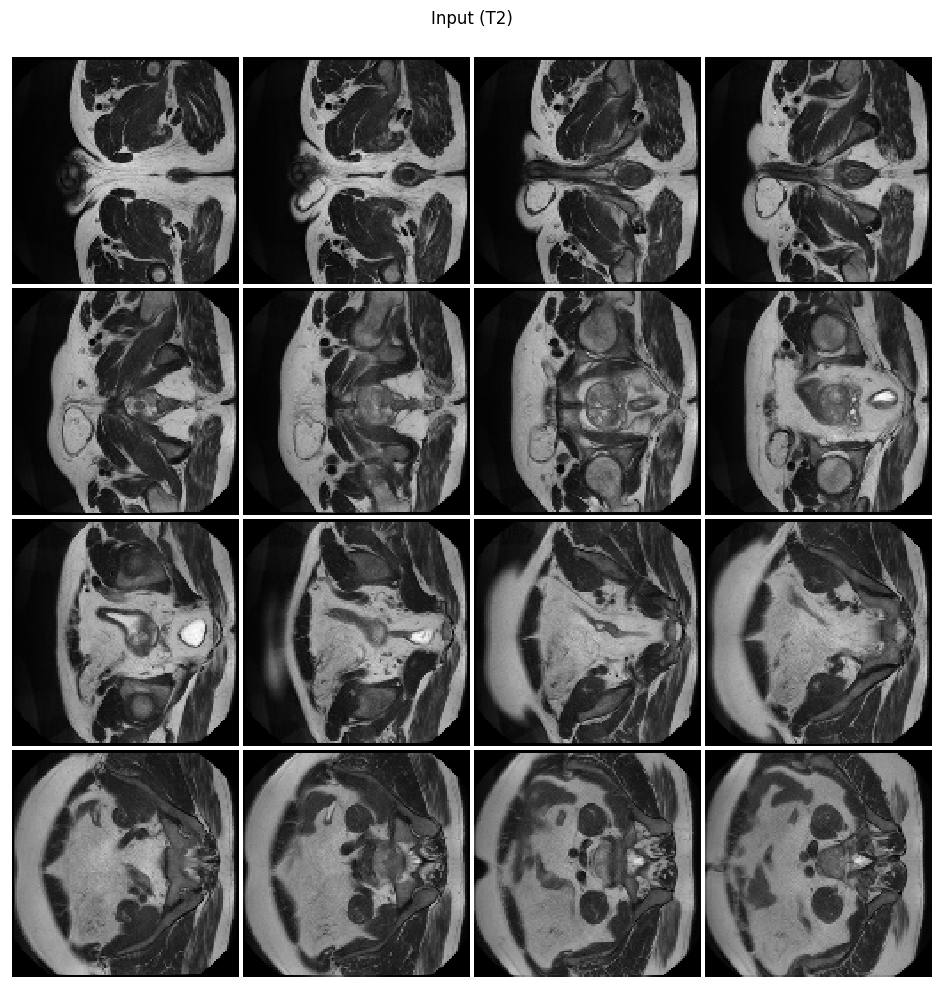

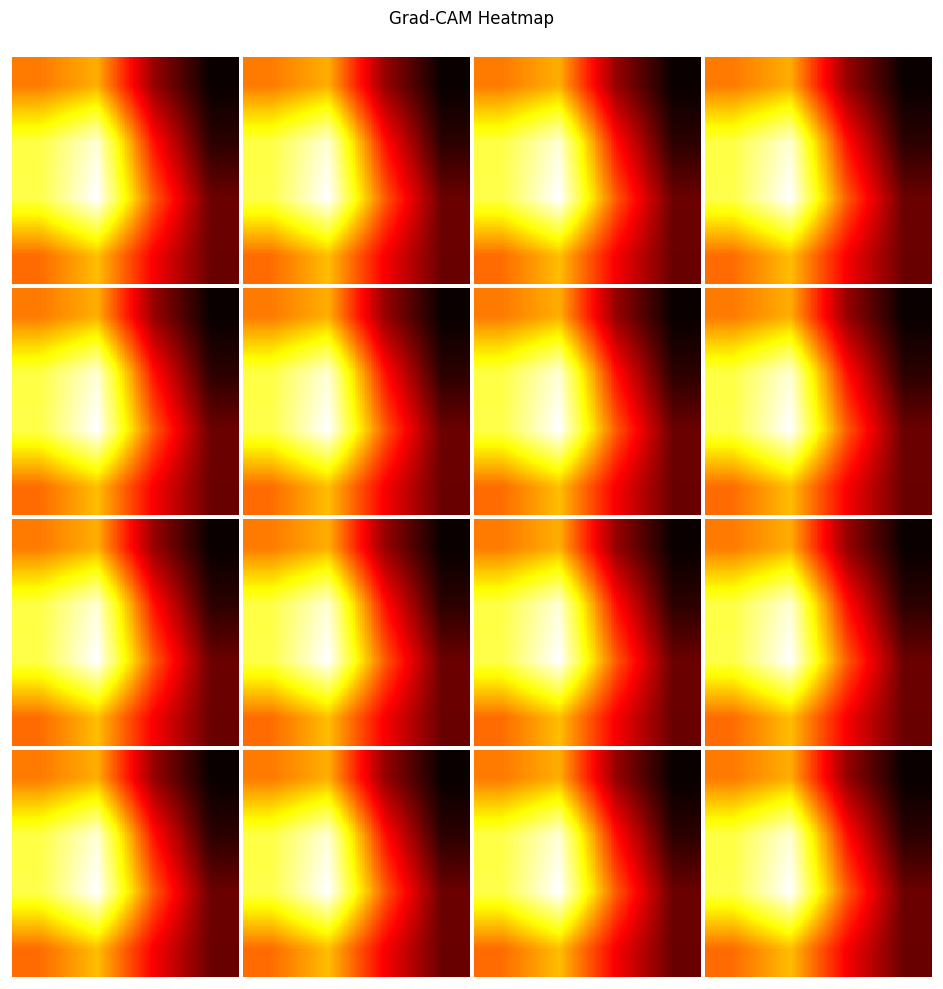

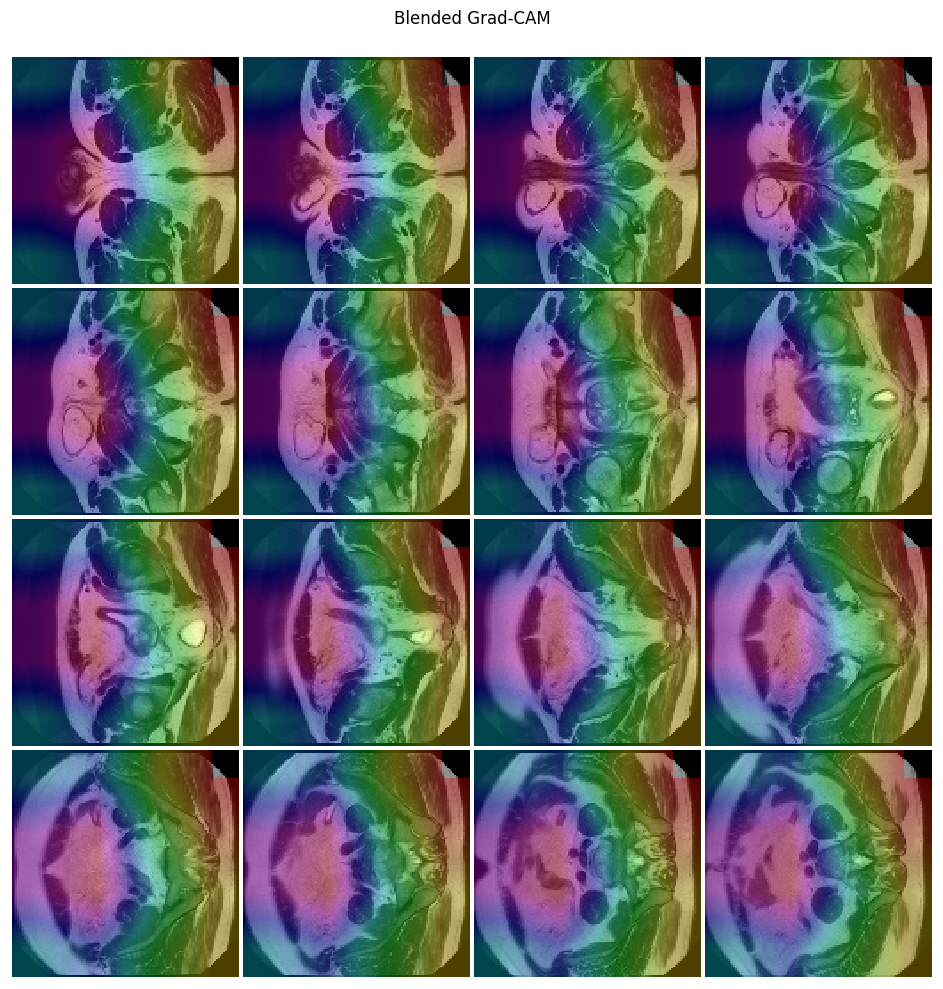

In [23]:
# 3D Grad-CAM implementation for EfficientNet-B7 (works with current 'model')
# Uses hook-based vanilla Grad-CAM over the last conv head (model._conv_head)

class GradCAM3D:
    def __init__(self, model, target_module):
        self.model = model
        self.target_module = target_module
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_module.register_forward_hook(self._forward_hook)
        self.bwd_handle = target_module.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)  # shape (N, C)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        score = logits[:, class_idx]
        score.backward(retain_graph=False)

        # activations: (N, C_feat, H', W', D') or (N, C_feat, D', H', W')
        acts = self.activations
        grads = self.gradients

        # Try to detect spatial ordering; unify to (N,C,D,H,W) for interpolation
        if acts.dim() != 5:
            raise RuntimeError("Expected 5D activations for 3D Grad-CAM.")
        # Heuristic: if the 3rd dim is much smaller than 4th it's probably (N,C,H,W,D)
        # Reorder to (N,C,D,H,W)
        if acts.shape[2] <= 64 and acts.shape[-1] >= 64:  # likely (N,C,H,W,D)
            acts_perm = acts.permute(0, 1, 4, 2, 3)
            grads_perm = grads.permute(0, 1, 4, 2, 3)
        else:  # assume already (N,C,D,H,W)
            acts_perm = acts
            grads_perm = grads

        # Global average pooling over (D,H,W)
        weights = grads_perm.mean(dim=(2, 3, 4), keepdim=True)  # (N,C,1,1,1)
        cam = (weights * acts_perm).sum(dim=1, keepdim=True)    # (N,1,D,H,W)
        cam = torch.relu(cam)

        # Upsample to input size
        in_shape = x.shape  # (N,C,?, ?, ?) original order maybe (N,C,H,W,D)
        if in_shape[2] <= 64 and in_shape[-1] >= 64:  # (N,C,H,W,D)
            target_size = (in_shape[-1], in_shape[2], in_shape[3])  # (D,H,W)
        else:  # (N,C,D,H,W)
            target_size = in_shape[2], in_shape[3], in_shape[4]

        cam_up = torch.nn.functional.interpolate(
            cam, size=target_size, mode="trilinear", align_corners=False
        )

        # Return in original spatial ordering as (N,1,H,W,D)
        if in_shape[2] <= 64 and in_shape[-1] >= 64:  # original (N,C,H,W,D)
            cam_up = cam_up.permute(0, 1, 2, 3, 4)              # (N,1,D,H,W)
            cam_up = cam_up.permute(0, 1, 3, 4, 2).contiguous() # (N,1,H,W,D)

        # Normalize 0-1
        cam_up = cam_up - cam_up.min()
        if cam_up.max() > 0:
            cam_up = cam_up / cam_up.max()
        return cam_up, class_idx

# Instantiate Grad-CAM
gc3d = GradCAM3D(model, model.model._conv_head)  # uses same target layer as prior CAM

# Select a random validation sample (reuse test_dataloader from earlier section if desired)
idx = np.random.randint(0, len(test_dataloader))
sample = test_dataloader.dataset[idx]
img = sample["image"].to(device)  # shape (C,H,W,D)
label = sample["label"]
input_tensor = img.unsqueeze(0)   # (1,C,H,W,D)

with torch.no_grad():
    pred_probs = torch.softmax(model(input_tensor), dim=1)
pred_class = pred_probs.argmax(dim=1).item()

cam_vol, used_class = gc3d(input_tensor, class_idx=pred_class)  # (1,1,H,W,D)
cam_channel = cam_vol[0, 0]  # (H,W,D)

# Blend over a chosen modality channel (e.g., channel 0 = T2)
base = img[0:1].detach().cpu()  # (1,H,W,D)
heat = cam_channel.unsqueeze(0).cpu()  # (1,H,W,D)

blended = monai.visualize.utils.blend_images(255 * base, 255 * heat, alpha=0.3, transparent_background=True)

print(f"Idx {idx} | True class: {label.argmax().item() if label.ndim>0 else int(label)} | Pred class: {pred_class}")
monai.visualize.matshow3d(volume=base, frame_dim=-1, channel_dim=0, every_n=2, cmap="gray", show=False)
plt.title("Input (T2)"); plt.show()

monai.visualize.matshow3d(volume=heat, frame_dim=-1, channel_dim=0, every_n=2, cmap="hot", show=False)
plt.title("Grad-CAM Heatmap"); plt.show()

monai.visualize.matshow3d(volume=blended, frame_dim=-1, channel_dim=0, every_n=2, show=False)
plt.title("Blended Grad-CAM"); plt.show()

# Optional: save figure
# plt.imsave(os.path.join(figures_dir, f"gradcam_example.{extension}"), blended[0,...,blended.shape[-1]//2].numpy(), cmap="hot")

# Cleanup (optional if you plan to reuse)
# gc3d.remove_hooks()

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional

# --------- selección robusta de la capa objetivo ---------
def pick_target_module_3d(model: nn.Module) -> nn.Module:
    """
    Devuelve la última nn.Conv3d con kernel > 1 y stride == 1.
    Evita el _conv_head 1x1 y capas con downsampling.
    """
    target = None
    for m in model.modules():
        if isinstance(m, nn.Conv3d):
            k = m.kernel_size if isinstance(m.kernel_size, tuple) else (m.kernel_size,)*3
            s = m.stride if isinstance(m.stride, tuple) else (m.stride,)*3
            if max(k) > 1 and max(s) == 1:
                target = m
    if target is None:
        raise RuntimeError("No se encontró Conv3d adecuado. Revisa la arquitectura.")
    return target

# --------- Grad-CAM 3D mínimo y estable ---------
class GradCAM3D:
    def __init__(self, model: nn.Module, target_module: nn.Module):
        self.model = model
        self.target_module = target_module
        self.activations = None
        self.gradients = None
        self.fh = target_module.register_forward_hook(self._fwd_hook)
        self.bh = target_module.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        # Espera (N,C,H,W,D)
        self.activations = out.detach()

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove(self):
        self.fh.remove(); self.bh.remove()

    @torch.no_grad()
    def normalize_(self, cam):
        cam -= cam.amin(dim=(2,3,4), keepdim=True)
        cam_max = cam.amax(dim=(2,3,4), keepdim=True)
        cam /= (cam_max + 1e-6)
        return cam

    def __call__(self, x: torch.Tensor, class_idx: Optional[int] = None):
        assert x.dim() == 5, "Esperado (N,C,H,W,D)"
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)              # (N,num_classes)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1))
        score = logits[:, class_idx]
        score.backward()

        acts  = self.activations            # (N,C,H,W,D)
        grads = self.gradients              # (N,C,H,W,D)
        if acts is None or grads is None:
            raise RuntimeError("Hooks sin datos. Verifica target_module y .eval().")

        weights = grads.mean(dim=(2,3,4), keepdim=True)         # (N,C,1,1,1)
        cam = torch.relu((weights * acts).sum(dim=1, keepdim=True))  # (N,1,H,W,D)
        cam = self.normalize_(cam)
        return cam, class_idx

# --------- uso ---------
model.eval()  # BN/Dropout fijos

target_module = pick_target_module_3d(model)   # evita _conv_head
gc3d = GradCAM3D(model, target_module)


idx = 45
sample = test_dataloader.dataset[idx]
img = sample["image"].to(device)  # shape (C,H,W,D)
label = sample["label"]
input_tensor = img.unsqueeze(0)   # (1,C,H,W,D)

# x: (1,C,H,W,D)
with torch.no_grad():
    probs = torch.softmax(model(input_tensor), dim=1)
pred_class = int(probs.argmax(dim=1))

cam, _ = gc3d(input_tensor, class_idx=pred_class)         # (1,1,H,W,D)
heat = cam[0,0:1]                               # (1,H,W,D) en [0,1]

ncdhw = heat.unsqueeze(0).permute(0, 1, 4, 2, 3)   # -> (N=1, C=1, D, H, W)

D, H, W = ncdhw.shape[-3:]
ks = (min(3, D), min(3, H), min(3, W))             # nunca mayor que cada eje
pad = (ks[0]//2, ks[1]//2, ks[2]//2)

ncdhw = F.avg_pool3d(ncdhw, kernel_size=ks, stride=1, padding=pad)

heat = ncdhw.permute(0, 1, 3, 4, 2).squeeze(0)     # vuelve a (1, H, W, D)

# # opcional: suavizado ligero
# heat = F.avg_pool3d(heat.unsqueeze(0), 3, stride=1, padding=1).squeeze(0)

# visualización MONAI: mezcla correcta en [0,1]
base = input_tensor[0,0:1].detach().cpu().float()         # canal elegido
heat = heat.detach().cpu().float()
blended = monai.visualize.utils.blend_images(base, heat, alpha=0.35, transparent_background=False)

# mostrar
monai.visualize.matshow3d(volume=base, frame_dim=-1, channel_dim=0, every_n=2, cmap="gray", show=False); plt.title("Input"); plt.show()
monai.visualize.matshow3d(volume=heat, frame_dim=-1, channel_dim=0, every_n=2, cmap="hot",  show=False); plt.title("Grad-CAM"); plt.show()
monai.visualize.matshow3d(volume=blended, frame_dim=-1, channel_dim=0, every_n=2,            show=False); plt.title("Blended"); plt.show()


ValueError: image and label should have matching spatial sizes.

In [33]:
base.shape

torch.Size([1, 128, 128, 32])

In [34]:
heat.shape

torch.Size([1, 4, 4, 1])

In [29]:
cam.shape

torch.Size([1, 1, 4, 4, 1])

In [84]:
gbp_result.max()

metatensor(255.)

In [46]:
result.shape

torch.Size([3, 128, 128, 32])

In [48]:
cam_result.shape

torch.Size([1, 128, 128, 32])

## no csPCa

In [330]:
idx=np.random.randint(0,len(test_dataloader))
img, label = (test_dataloader.dataset[idx]['image'].to(device),test_dataloader.dataset[idx]['label'])
print(img.shape, label.shape)
label

torch.Size([3, 128, 128, 32]) torch.Size([2])


tensor([1., 0.])

In [331]:
with torch.no_grad():
    print(torch.nn.functional.softmax(model(img.unsqueeze(0)), dim=1))

metatensor([[0.9400, 0.0600]], device='cuda:0')


In [332]:
no_csPCa = (maps["no_csPCa"] - maps["no_csPCa"].min())/(maps["no_csPCa"].max() - maps["no_csPCa"].min())

NameError: name 'maps' is not defined

In [333]:
blended = monai.visualize.utils.blend_images(255*img.squeeze(0).cpu()[0:1], 
                                             255*torch.where(no_csPCa.cpu()[0:1] > 0.7, no_csPCa.cpu()[0:1], 0), 
                                             alpha=0.3,
                                             transparent_background=True)
monai.visualize.matshow3d(volume=blended, frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
plt.show()

NameError: name 'no_csPCa' is not defined

## csPCa

In [686]:
idx=np.random.randint(0,len(test_dataloader))
img, label = (test_dataloader.dataset[idx]['image'].to(device),test_dataloader.dataset[idx]['label'])
print(img.shape, label.shape)
label

torch.Size([3, 128, 128, 32]) torch.Size([2])


tensor([0., 1.])

In [687]:
with torch.no_grad():
    print(torch.nn.functional.softmax(model(img.unsqueeze(0)), dim=1))

metatensor([[0.0060, 0.9940]], device='cuda:0')


In [688]:
csPCa = (maps["csPCa"] - maps["csPCa"].min())/(maps["csPCa"].max() - maps["csPCa"].min())

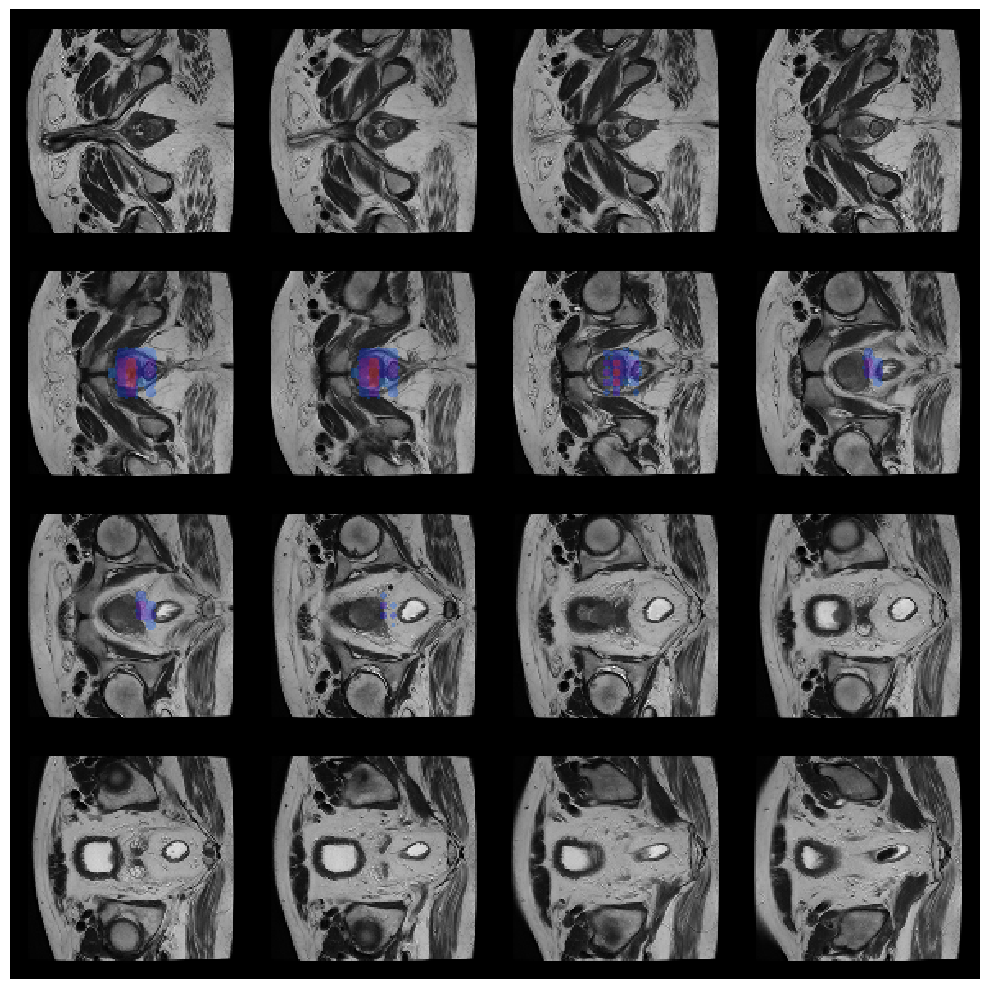

In [428]:
blended = monai.visualize.utils.blend_images(255*img.squeeze(0).cpu()[0:1], 
                                             255*torch.where(csPCa.cpu()[0:1] > 0.6, csPCa.cpu()[0:1], 0), 
                                             alpha=0.3,
                                             transparent_background=True)
monai.visualize.matshow3d(volume=blended, frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
plt.savefig(os.path.join(figures_dir,"model_interpretation."+extension), dpi=500, bbox_inches='tight')
plt.show()

## Get Individual heatmap

In [780]:
idx=np.random.randint(0,len(test_dataloader))
img, label = (test_dataloader.dataset[idx]['image'].to(device),test_dataloader.dataset[idx]['label'])
print(img.shape, label.shape)
label

torch.Size([3, 128, 128, 32]) torch.Size([2])


tensor([0., 1.])

In [781]:
heatmap = torch.load(f"Prostate_Cancer_TFM/Classification/sensitivity_maps/class{label.argmax().item()}_{os.path.basename(img.meta['filename_or_obj'])}")

In [782]:

heatmap = (heatmap - heatmap.min())/(heatmap.max() - heatmap.min())

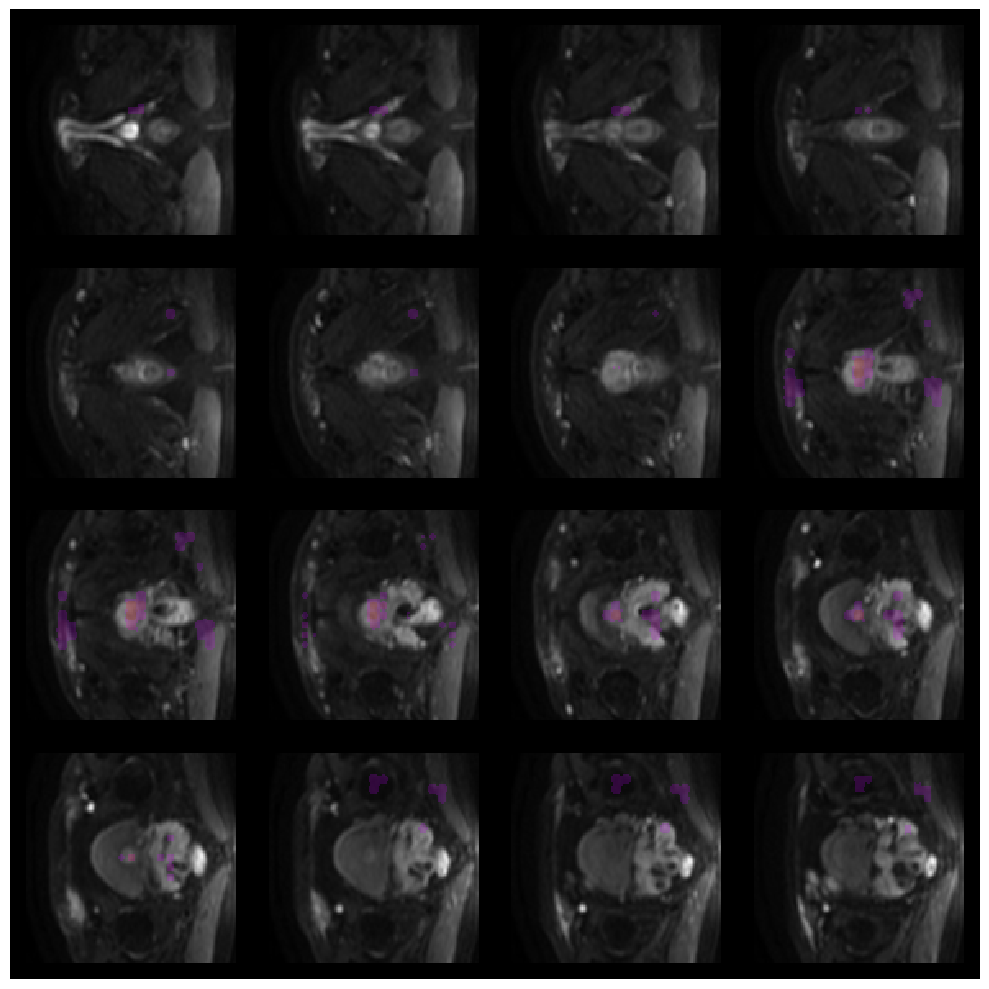

In [783]:
blended = monai.visualize.utils.blend_images(255*img.squeeze(0).cpu()[1:2], 
                                            255*torch.where(heatmap.cpu()[0:1] > 0.8, heatmap.cpu()[0:1], 0), 
                                            alpha=0.2,
                                            transparent_background=True)
monai.visualize.matshow3d(volume=blended, frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
plt.show()

In [334]:
import nibabel as nib

ras_pos = (255*blended.permute(1,2,3,0)).astype(torch.uint8).cpu().numpy()
shape_3d = ras_pos.shape[0:3]
rgb_dtype = np.dtype([('R', 'u1'), ('G', 'u1'), ('B', 'u1')])
ras_pos = ras_pos.copy().view(dtype=rgb_dtype).reshape(shape_3d)  # copy used to force fresh internal structure
ni_img = nib.Nifti1Image(ras_pos, img.affine)
nib.save(ni_img, "Prostate_Cancer_TFM/Classification/resized.nii.gz")

## Checking External Image

In [787]:
import monai

In [800]:
## Defining transforms
img_columns = ["t2", "dwi", "adc"]
input_shape = (128, 128, 32)    
val_transforms = monai.transforms.Compose([
            monai.transforms.LoadImaged(keys=img_columns, image_only=True,ensure_channel_first=True),
            monai.transforms.ResampleToMatchd(
                keys=["adc", "dwi"],
                key_dst="t2",
                mode=("bilinear", "bilinear"),
            ), # Resample images to t2 dimension
            monai.transforms.SplitDimd(
                keys=["dwi"],
                keepdim=True,
            ), 
            monai.transforms.Resized(
                keys=['t2','dwi_0','adc'],
                spatial_size=input_shape,
                mode=("trilinear", "trilinear", "trilinear"),
            ),
            monai.transforms.ScaleIntensityd(keys=['t2','dwi_0','adc'], minv=0.0, maxv=1.0, allow_missing_keys=True),
            monai.transforms.ConcatItemsd(keys=['t2','dwi_0','adc'], name="image", dim=0),
            monai.transforms.SelectItemsd(keys=["image", "label"])
        ])

In [801]:
img_dict = {"t2":"/home/jaalzate/video_tartaglia/11002_1001021_t2w/11002_1001021_t2w_img.nii.gz",
            "dwi":"/home/jaalzate/video_tartaglia/11002_1001021_hbv/11002_1001021_hbv_img.nii.gz",
            "adc":"/home/jaalzate/video_tartaglia/11002_1001021_adc/11002_1001021_adc_img.nii.gz",
            "label": "/home/jaalzate/video_tartaglia/11002_1001021_t2w/11002_1001021_t2w_seg.nii.gz"}

In [802]:
img_dict = val_transforms(img_dict)

invalid value encountered in cast


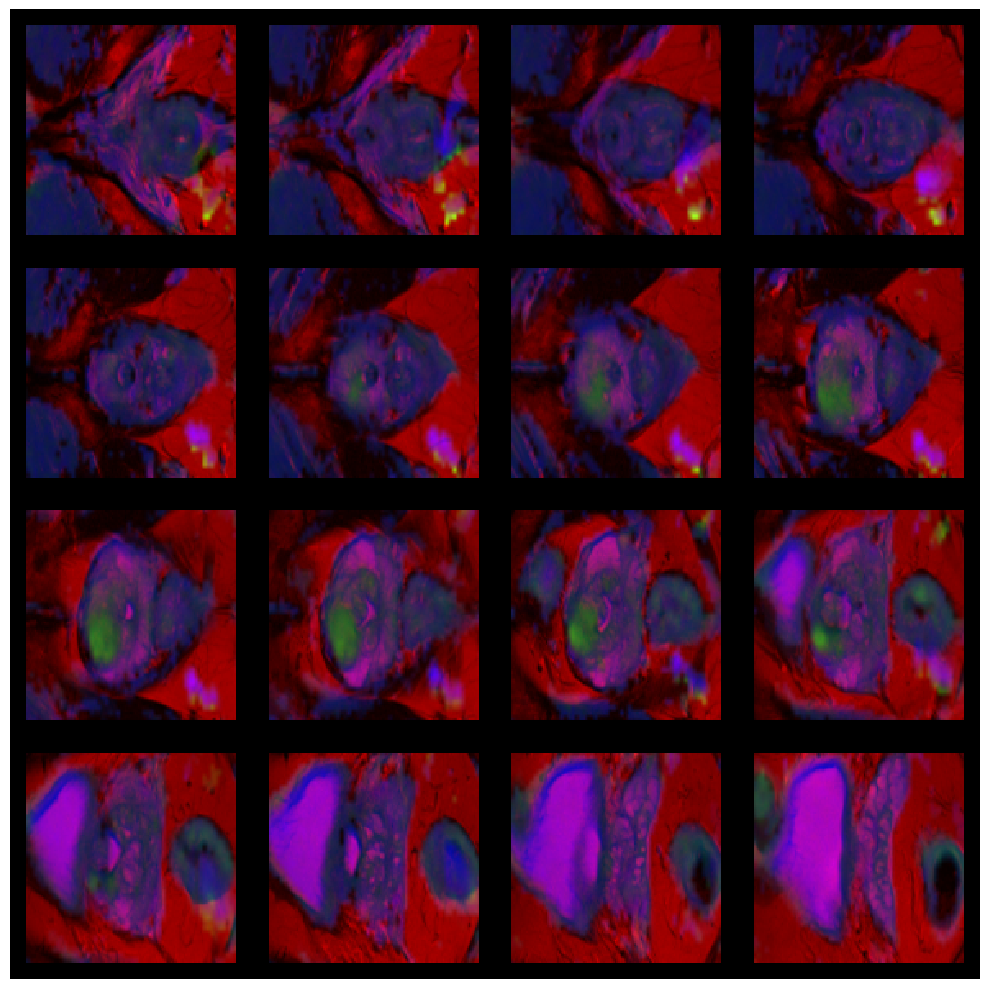

In [803]:
#plot image
img = img_dict["image"]
monai.visualize.matshow3d(volume=img.cpu(), frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False,cmap='gray')
plt.show()

In [ ]:
monai.visualize.matshow3d(volume=img.cpu()[1:2], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False,cmap='gray')
plt.show()

monai.visualize.matshow3d(volume=result[0:1], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
plt.show()

torch.Size([3, 128, 128, 32])


Computing GuidedBackpropSmoothGrad: 100%|██████████| 50/50 [00:07<00:00,  6.63it/s]


torch.Size([3, 128, 128, 32])


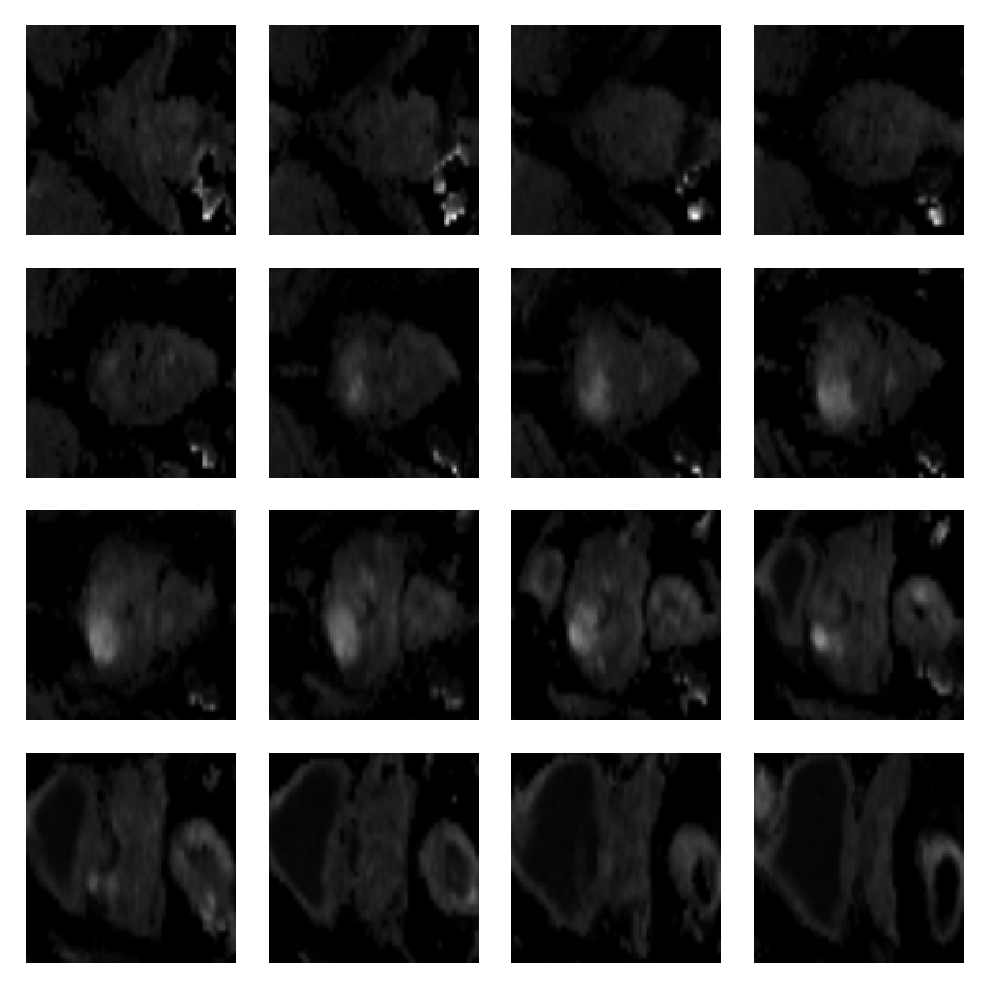

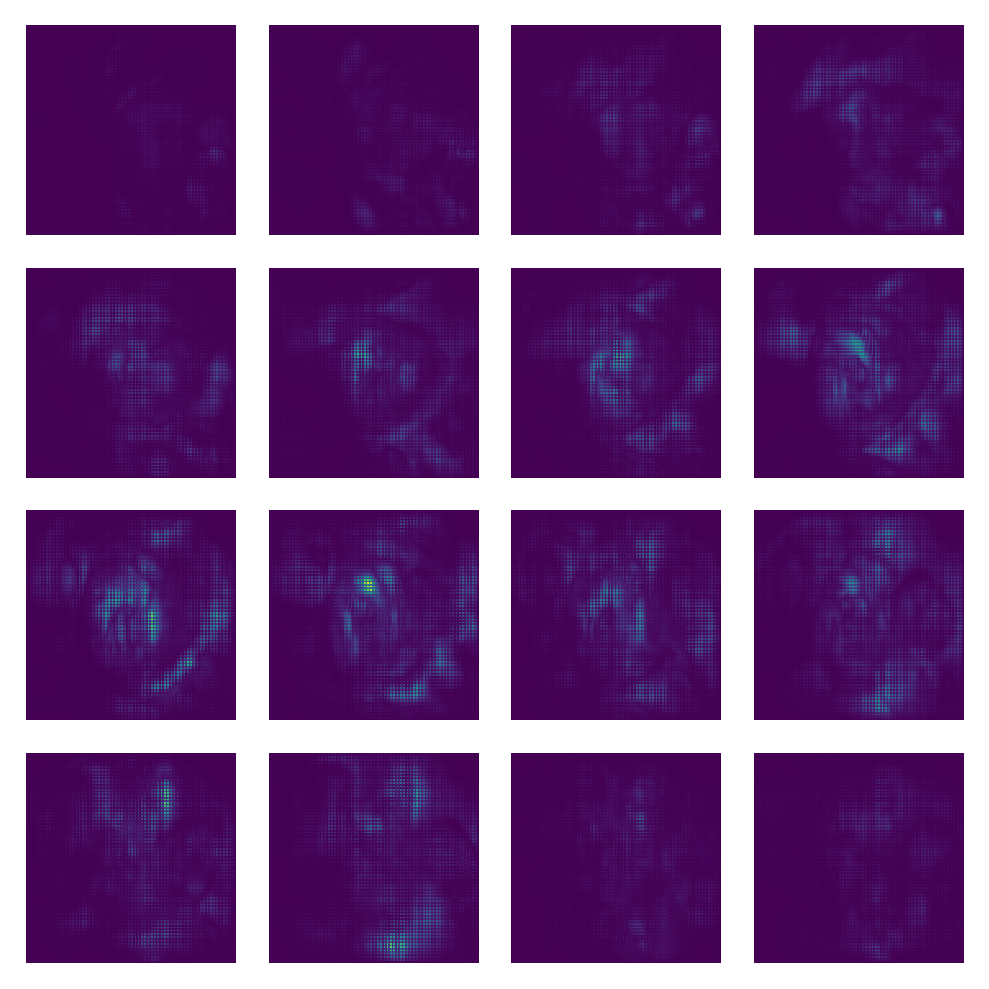

In [804]:
# Testing GradCAM
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
#model.requires_grad_=True
cam = monai.visualize.class_activation_maps.CAM(nn_module=model, target_layers="model._conv_head", fc_layers="model._fc")
gbp = monai.visualize.gradient_based.GuidedBackpropSmoothGrad(model,n_samples=50)
#with torch.no_grad():    

#idx=np.random.randint(0,len(test_dataloader))
#img, label = (test_dataloader.dataset[idx]['image'].to(device),test_dataloader.dataset[idx]['label'])
print(img.shape)
img = img.to(device)
#print(label)
pred_label = torch.nn.functional.softmax(model(img.unsqueeze(0)), dim=1).argmax().item()


cam_result = cam(x=img.unsqueeze(0)).squeeze(0).cpu()
gbp_result = gbp(x=img.unsqueeze(0)).squeeze(0).cpu()

gbp_result = (gbp_result - gbp_result.min())/(gbp_result.max() - gbp_result.min())
cam_result = (cam_result - cam_result.min())/(cam_result.max() - cam_result.min())

#cam_result = 255*torch.where(cam_result.cpu() > 0.9, cam_result.cpu(), 0)
#gbp_result = 255*torch.where(gbp_result.cpu() < 0.3, gbp_result.cpu(), 1)

result = cam_result * gbp_result

print(result.shape)

result = (result - result.min())/(result.max() - result.min())
# Plot the GradCAM result
blended = monai.visualize.utils.blend_images(255*img.cpu()[2:3], 
                                            gbp_result[1:2], 
                                            alpha=0.1,
                                            transparent_background=True)
monai.visualize.matshow3d(volume=img.cpu()[1:2], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False,cmap='gray')
plt.show()

monai.visualize.matshow3d(volume=result[0:1], frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
plt.show()

In [805]:
pred_label

0

# Check BIMCV test partition results

In [27]:
import pandas as pd
import numpy as np
import os
import torch
from monai import transforms
from torch import as_tensor
from torch.nn.functional import one_hot
from monai.data import CacheDataset, DataLoader
from models import EfficientNet_pretrained

In [28]:
df = pd.read_csv("/home/ceib/jaalzate/BIMCV-Prostate-Classification/Files/data_with_splits_dep_disjoint.csv")

df_test = df[df["split"]=="test"]
df_test

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,split
0,sub-002726,ses-004030,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,75.0,NaN,NaN,NaN,6.70,NaN,2.0,0.0,1944-07-28,2020-05-02,train,False,NaN,test
1,sub-003019,ses-003234,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,70.0,NaN,NaN,NaN,19.50,NaN,5.0,0.0,1941-11-29,2012-01-31,train,False,NaN,test
2,sub-008321,ses-009264,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,69.0,NaN,NaN,NaN,6.47,NaN,3.0,1.0,1944-04-16,2013-07-28,train,False,NaN,test
3,sub-008321,ses-009264,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,69.0,NaN,NaN,NaN,6.47,NaN,3.0,1.0,1944-04-16,2013-07-28,train,False,NaN,test
4,sub-003327,ses-003551,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,57.0,NaN,NaN,NaN,12.60,NaN,3.0,0.0,1959-01-05,2016-12-05,train,False,NaN,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,sub-000409,ses-000425,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,21.0,71.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1942-10-07,2013-11-16,train,False,NaN,test
577,sub-000871,ses-000936,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,21.0,59.0,11.0,NaN,NaN,NaN,NaN,NaN,1.0,1952-11-28,2012-01-25,train,False,NaN,test
578,sub-000871,ses-000936,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,21.0,59.0,11.0,NaN,NaN,NaN,NaN,NaN,1.0,1952-11-28,2012-01-25,train,False,NaN,test
579,sub-001432,ses-001546,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,21.0,71.0,NaN,NaN,NaN,8.32,NaN,NaN,1.0,1936-04-15,2007-06-21,train,False,NaN,test


In [29]:
df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("ceib/", ""))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("ceib/", ""))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("ceib/", ""))

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("prueba/", ""))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("prueba/", ""))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("prueba/", ""))



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [30]:
img_columns=["t2", "adc", "dwi"]
input_shape = (128, 128, 32)
val_transforms = transforms.Compose([
        transforms.LoadImaged(keys=img_columns, image_only=True,ensure_channel_first=True),
        transforms.ResampleToMatchd(
            keys=["adc", "dwi"],
            key_dst="t2",
            mode=("bilinear", "bilinear"),
        ), # Resample images to t2 dimension
        transforms.SplitDimd(
            keys=["dwi"],
            keepdim=True,
        ), 
        transforms.Resized(
            keys=['t2','dwi_0','adc'],
            spatial_size=input_shape,
            mode=("trilinear", "trilinear", "trilinear"),
        ),
        transforms.ScaleIntensityRangePercentilesd(keys=['adc'], lower=5, upper=99.5,b_min=0.0, b_max=1.0,clip=True),
        transforms.ScaleIntensityd(keys=['t2','dwi_0'], minv=0.0, maxv=1.0, allow_missing_keys=True),
        transforms.ConcatItemsd(keys=['t2','dwi_0','adc'], name="image", dim=0),
        transforms.SelectItemsd(keys=["image", "label"])
        ])

In [22]:
data = [
            {"t2": t2, "adc": adc, "dwi": dwi, "label": label}
            for t2, adc, dwi, label in zip(
                df_test["image_t2"].values,
                df_test["image_adc"].values,
                df_test["image_dwi"].values,
                one_hot(as_tensor(df_test["csPC"].values, dtype=int)).float(),
            )
        ]

In [24]:
dataset = CacheDataset(data=data, transform=val_transforms, num_workers=7)

Loading dataset: 100%|██████████| 581/581 [04:10<00:00,  2.32it/s]


In [25]:
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=7)

In [45]:
pretrained_weights_path = 'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/models/best-model-weights.pth'
model = EfficientNet_pretrained(model_name = "efficientnet-b7",
                                n_classes = 2, 
                                in_channels_eff = 3,
                                pretrained_weights_path = None)

model.load_state_dict(torch.load(pretrained_weights_path)["state_dict"])

<All keys matched successfully>

In [46]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

EfficientNet_pretrained(
  (model): EfficientNetBN(
    (_conv_stem): Conv3d(3, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), bias=False)
    (_conv_stem_padding): ConstantPad3d(padding=(0, 1, 0, 1, 0, 1), value=0.0)
    (_bn0): BatchNorm3d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (_blocks): Sequential(
      (0): Sequential(
        (0): MBConvBlock(
          (_expand_conv): Identity()
          (_expand_conv_padding): Identity()
          (_bn0): Identity()
          (_depthwise_conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), groups=64, bias=False)
          (_depthwise_conv_padding): ConstantPad3d(padding=(1, 1, 1, 1, 1, 1), value=0.0)
          (_bn1): BatchNorm3d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (_se_adaptpool): AdaptiveAvgPool3d(output_size=1)
          (_se_reduce): Conv3d(64, 16, kernel_size=(1, 1, 1), stride=(1, 1, 1))
          (_se_reduce_padding): Identity()
          (_se_expand): 

In [48]:
from tqdm import tqdm
# Evaluate the model on the test set (with progress bar)
model.eval()
true_labels = []
pretrained_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Evaluating test", total=len(dataloader)):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # positive class probs
        pretrained_predictions.extend(probs.cpu().tolist())
        true_labels.extend(labels[:, 1].cpu().tolist())  # assuming one-hot labels

Evaluating test: 100%|██████████| 581/581 [00:43<00:00, 13.22it/s]


In [49]:
len(true_labels), len(pretrained_predictions)

(581, 581)

In [50]:
#Classification report
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(true_labels, np.array(pretrained_predictions)>0.5, target_names=['No csPCa', 'csPCa']))

              precision    recall  f1-score   support

    No csPCa       0.55      0.63      0.59       235
       csPCa       0.72      0.65      0.68       346

    accuracy                           0.64       581
   macro avg       0.63      0.64      0.63       581
weighted avg       0.65      0.64      0.64       581



In [53]:
auc_roc_pretrained

0.6678391341778379

In [52]:
# Calculate metrics
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import plotly.graph_objects as go
fpr_pretrained, tpr_pretrained, _ = roc_curve(true_labels, pretrained_predictions)
auc_roc_pretrained = auc(fpr_pretrained, tpr_pretrained)

# Create the ROC curve plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fpr_pretrained, y=tpr_pretrained,
    mode='lines', name=f'Pre-trained model (AUC = {auc_roc_pretrained:.2f})',
    line=dict(color='darkorange', width=2),
))

fig.update_layout(
    title='Receiver Operating Characteristic (ROC) Curve',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    legend=dict(x=0.4, y=0.1),
    width=800, height=600,
    font=dict(size=16),
    margin=dict(l=50, r=50, t=50, b=50),
)